# Build Event Catalog

In [1]:
# imports, workspace path, and catalog runtime.
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from pyextremes import get_extremes
import pyvinecopulib as pvc

# distribution, severity, and scaling plots.
from design_events import plotting as P
# paths and severity bands.
from design_events.build_events.workflow import assign_severity_bands, load_runtime
# historical water levels for coastal event statistics.
from design_events.fit_history.peaks import load_hourly_waterlevel
# turn historical peaks into auditable frequency tables.
from design_events.fit_history.return_curve import HistoricalPeakMarginal, marginal_params_frame, marginal_rps_frame
# stress-event selection and Wflow/SFINCS inputs.
from design_events.build_events.workflow import (
    attach_antecedent_soil_moisture,
    select_training,
)
# pair observed forcings and build member libraries for catalog sampling.
from design_events.fit_history.driver_records import assemble_paired_observations_from_config, build_member_libraries
# inland/joint design-event catalogs and historical-tail samples.
from design_events.build_events.probability.design_catalog import build_tail, build_joint_catalog
# tide/surge decomposition, NTR marginal fitting, and coastal policy wiring.
from design_events.fit_history.tidal import coastal_components
from design_events.fit_history.storm_type import classify_from_config
from design_events.build_events.probability.design_catalog import fit_index_marginal
from design_events.build_events.workflow import configure_coastal_dependence_policy, configure_coastal_design_event_policy
# packages coastal catalog forcing for SFINCS scenarios.
from sfincs_runs.scenarios.joint_handoff import write_handoff
from sfincs_runs.scenarios.coastal_realization import build_timeseries


pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

runtime = load_runtime(location_root)
config = runtime.config
paths = runtime.runtime_paths
location_name = runtime.location_name


/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Design Event Catalogue Parameters

**importance-sampling and resource-allocation design** — Every selected row keeps its `probability_weight`, so enriching this set toward tail-heavy events does not bias the annualised estimate (Average Annual Outcome / EAD) — the weights correct the integral. This allows for oversampling the interesting events without distorting the risk number.

Design event split is user-driven. For this coastal joint catalog, a tail-heavy 5/20/20/25/30 split is selected for 500 events.


In [2]:
# design-event simulation budget, coastal copula method, and severity mix.
resilience_stress_training = configure_coastal_design_event_policy(config)
benchmark_return_periods = resilience_stress_training["benchmark_return_period_years"]


## Stage 1 — Source inventory

Configure the forcing-member tables used by the coastal catalog.

In [3]:
forcing_member_paths = {
    "rainfall": "data/sources/aorc_sst/rainfall_members.csv",
    "streamflow": None,
    "soil_moisture": "data/sources/nwm/soil_moisture.csv",
}
config.setdefault("event_catalog", {})["forcing_members"] = forcing_member_paths

### Pairing policy

Rainfall is seasonally permuted within a 45-day window to preserve storm season without requiring the same historical event. Soil moisture is selected 24 hours before the paired rainfall member.

In [4]:
pairing_policy = {
    "rainfall": {"strategy": "seasonal_window_permutation", "seed": 2, "window_days": 45},
    "soil_moisture": {
        "strategy": "antecedent_to_forcing",
        "reference_forcing": "rainfall",
        "lead_time_hours": 24,
    },
}
config["event_catalog"]["pairing"] = pairing_policy

source_pairing_parameters = pd.Series({
    "location": location_name,
    "rainfall_pairing": "seasonal permutation within +/-45 days",
    "rainfall_pairing_seed": pairing_policy["rainfall"]["seed"],
    "rainfall_pairing_window_days": pairing_policy["rainfall"]["window_days"],
    "soil_moisture_pairing": "nearest antecedent member before rainfall",
    "soil_moisture_lead_time_hours": pairing_policy["soil_moisture"]["lead_time_hours"],
}, name="source_pairing_parameters")
display(source_pairing_parameters)

location                                                        marshfield
rainfall_pairing                    seasonal permutation within +/-45 days
rainfall_pairing_seed                                                    2
rainfall_pairing_window_days                                            45
soil_moisture_pairing            nearest antecedent member before rainfall
soil_moisture_lead_time_hours                                           24
Name: source_pairing_parameters, dtype: object

### Source status

Check CORA coastal water level, ERA5/SnapWave coastal waves, AORC SST rainfall, and NWM soil moisture before loading driver libraries. Streamflow is listed as not required for this coastal catalog.

In [5]:
def source_artifact_status(filename):
    path = paths["source_artifacts_root"] / filename
    if not path.exists():
        return "missing"
    return str(json.loads(path.read_text(encoding="utf-8")).get("status", "unknown"))

source_inventory = pd.DataFrame([
    {
        "driver": "coastal_water_level",
        "source": "CORA boundary-node hourly water level",
        "role": "coastal event-index marginal, NTR/surge axis, and tide-preserving templates",
        "pairing_policy": "event_index",
        "path": str(paths["waterlevel_csv"]),
        "status": source_artifact_status("cora_boundary_water_level.json"),
    },
    {
        "driver": "coastal_waves",
        "source": "ERA5/SnapWave boundary forcing",
        "role": "wave forcing from the same historical coastal analog",
        "pairing_policy": "same_historical_analog",
        "path": str(paths["era5_waves_nc"]),
        "status": source_artifact_status("era5_snapwave_boundary_forcing.json"),
    },
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "role": "stochastic storm transposition rainfall members",
        "pairing_policy": pairing_policy["rainfall"]["strategy"],
        "path": str(paths["aorc_sst_rainfall_members_csv"]),
        "status": source_artifact_status("aorc_sst_rainfall_catalog.json"),
    },
    {
        "driver": "soil_moisture",
        "source": "NWM retrospective",
        "role": "antecedent hydrologic state for paired rainfall members",
        "pairing_policy": pairing_policy["soil_moisture"]["strategy"],
        "path": str(paths["nwm_soil_moisture_csv"]),
        "status": source_artifact_status("nwm_retrospective_hydrologic_state.json"),
    },
    {
        "driver": "streamflow",
        "source": "not used",
        "role": "not a configured boundary driver for the coastal Marshfield catalog",
        "pairing_policy": "not_required",
        "path": None,
        "status": "not_required",
    },
])

display(source_inventory)

,driver,source,role,pairing_policy,path,status
0,coastal_water_level,CORA boundary-node hourly water level,"coastal event-index marginal, NTR/surge axis, ...",event_index,/home/grahamhults/projects/Flood-RM/locations/...,complete
1,coastal_waves,ERA5/SnapWave boundary forcing,wave forcing from the same historical coastal ...,same_historical_analog,/home/grahamhults/projects/Flood-RM/locations/...,complete
2,rainfall,Direct AORC SST,stochastic storm transposition rainfall members,seasonal_window_permutation,/home/grahamhults/projects/Flood-RM/locations/...,complete
3,soil_moisture,NWM retrospective,antecedent hydrologic state for paired rainfal...,antecedent_to_forcing,/home/grahamhults/projects/Flood-RM/locations/...,complete
4,streamflow,not used,not a configured boundary driver for the coast...,not_required,NaN,not_required


## Stage 2 — Driver libraries and marginal evidence

CORA supplies the coastal water-level frequency axis used for Coastal Driver Return Period labels and same-analog wave timing. 

Direct AORC SST supplies rainfall members. 

NWM supplies antecedent wetness. 

ERA5/SnapWave metadata stays tied to the same historical coastal analog as the CORA template. 

The catalog is therefore driver-first and pairing-explicit, not a univariate flood model.

- Total water level is used as the boundary condition, but the dependence driver is the non-tidal residual (NTR).
- Marginal diagnostics transform observed peaks into return periods through fitted exceedance distributions.
- Soil moisture is retained as antecedent state, not a copula axis.

### 2.1 Driver Member Libraries

In [6]:
# driver member libraries for catalog sampling.
rainfall_members = pd.read_csv(paths["aorc_sst_rainfall_members_csv"])
soil_moisture_members = pd.read_csv(paths["nwm_soil_moisture_csv"])

# pair NWM source path to the frame
soil_moisture_members.attrs["source_file"] = str(paths["nwm_soil_moisture_csv"])

status_by_driver = source_inventory.set_index("driver")["status"].to_dict()
driver_library_summary = pd.DataFrame([
    {"driver": "coastal water level", "source": "CORA", "status": status_by_driver.get("coastal_water_level")},
    {"driver": "rainfall", "source": "Direct AORC SST", "status": status_by_driver.get("rainfall"), "member_rows": len(rainfall_members)},
    {"driver": "antecedent soil moisture", "source": "NWM retrospective", "status": status_by_driver.get("soil_moisture"), "member_rows": len(soil_moisture_members)},
    {"driver": "coastal waves", "source": "ERA5/SnapWave same coastal analog", "status": status_by_driver.get("coastal_waves")},
])
display(driver_library_summary)


,driver,source,status,member_rows
0,coastal water level,CORA,complete,NaN
1,rainfall,Direct AORC SST,complete,495.0
2,antecedent soil moisture,NWM retrospective,complete,4619232.0
3,coastal waves,ERA5/SnapWave same coastal analog,complete,NaN


### 2.1.2 SST Rainfall Distribution

,member_id,source,member_file,storm_start,storm_end,duration_hours,rank,annual_rank,mean_precip_mm,max_precip_mm,min_precip_mm,precip_units,potential_method,centroid_lon,centroid_lat,historical_centroid_lon,historical_centroid_lat,transposed_centroid_lon,transposed_centroid_lat,transposition_offset_lon,transposition_offset_lat,historical_footprint_center_lon,historical_footprint_center_lat,target_footprint_center_lon,target_footprint_center_lat,transposition_region_id
0,rainfall_marshfield_72h_rank0001,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2006-05-13T06:00:00,2006-05-16T06:00:00,72,1,1,297.733933,314.900005,279.300004,mm,moving_footprint_max_mean,-70.844033,42.815754,-70.844033,42.815754,-70.711456,42.11187,0.132577,-0.703884,-70.844033,42.815754,-70.711456,42.11187,east-atlantic-marshfield
1,rainfall_marshfield_72h_rank0002,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1996-10-19T12:00:00,1996-10-22T12:00:00,72,2,1,240.052682,254.600004,224.300003,mm,moving_footprint_max_mean,-70.910697,42.815754,-70.910697,42.815754,-70.711456,42.11187,0.199241,-0.703884,-70.910697,42.815754,-70.711456,42.11187,east-atlantic-marshfield
2,rainfall_marshfield_72h_rank0003,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2010-03-13T06:00:00,2010-03-16T06:00:00,72,3,1,224.723218,228.800003,220.600003,mm,moving_footprint_max_mean,-70.977361,42.682426,-70.977361,42.682426,-70.711456,42.11187,0.265905,-0.570556,-70.977361,42.682426,-70.711456,42.11187,east-atlantic-marshfield
3,rainfall_marshfield_72h_rank0004,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2011-08-25T18:00:00,2011-08-28T18:00:00,72,4,1,217.901789,251.600004,187.300003,mm,moving_footprint_max_mean,-71.644001,42.115782,-71.644001,42.115782,-70.711456,42.11187,0.932545,-0.003912,-71.644001,42.115782,-70.711456,42.11187,east-atlantic-marshfield
4,rainfall_marshfield_72h_rank0005,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2005-10-13T00:00:00,2005-10-16T00:00:00,72,5,1,217.861610,228.100003,202.500003,mm,moving_footprint_max_mean,-71.344013,41.682466,-71.344013,41.682466,-70.711456,42.11187,0.632557,0.429404,-71.344013,41.682466,-70.711456,42.11187,east-atlantic-marshfield


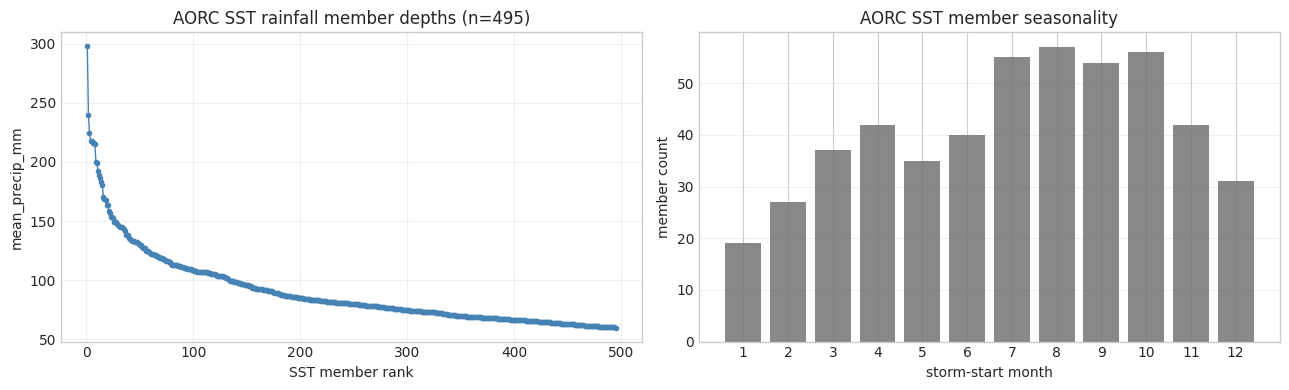

In [7]:
P.plot_rainfall(rainfall_members);
rainfall_members.head(5)

### 2.2 Coastal Water-Level Marginal Evidence

At a macro-tidal site the total-water-level peak is tide-saturated, so the coastal driver fed to the copula is the non-tidal residual (surge), fit in 2.2.8. Tide timing for wave forcing still uses the same historical coastal analog.

- Total water level: what water level did the coast experience?
- NTR separates surge and pairs it with rainfall driver.

### 2.2.1 Raw CORA Hourly Water Level


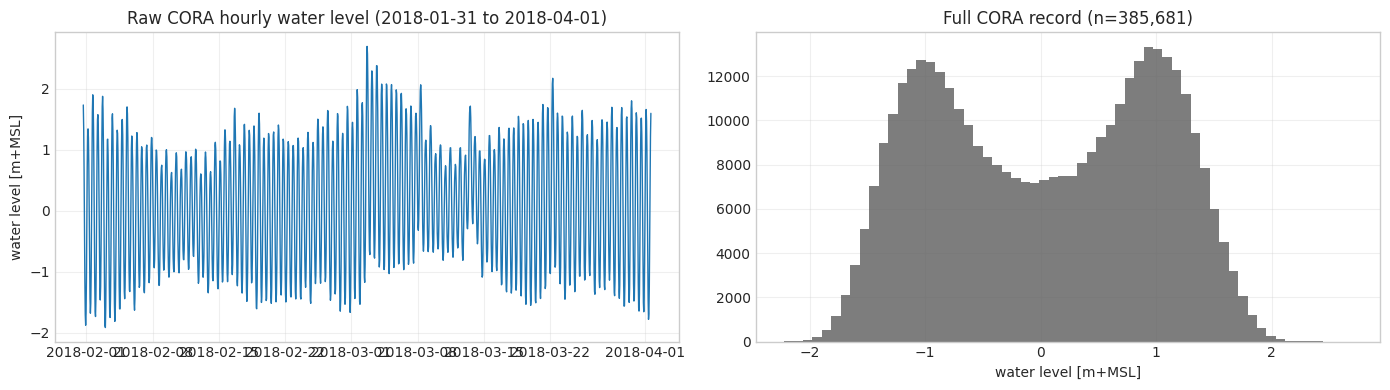

waterlevel_rows                      385681
waterlevel_start        1979-01-01 00:00:00
waterlevel_end          2022-12-31 00:00:00
raw_record_max_m                    2.69103
raw_record_peak_time    2018-03-02 16:00:00
Name: cora_waterlevel_record, dtype: object

In [8]:
# observed water levels for coastal POT evidence.
waterlevel = load_hourly_waterlevel(paths["waterlevel_csv"]).dropna().sort_index()
peak_time = waterlevel.idxmax()
window_slice = (peak_time - pd.Timedelta(days=30), peak_time + pd.Timedelta(days=30))
window = waterlevel.loc[window_slice[0]:window_slice[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0)
axes[0].set_title(f"Raw CORA hourly water level ({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})")
axes[0].set_ylabel("water level [m+MSL]")
axes[0].grid(True, alpha=0.3)
axes[1].hist(waterlevel.values, bins=60, color="0.4", alpha=0.85)
axes[1].set_title(f"Full CORA record (n={len(waterlevel):,})")
axes[1].set_xlabel("water level [m+MSL]")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "waterlevel_rows": len(waterlevel),
    "waterlevel_start": waterlevel.index.min(),
    "waterlevel_end": waterlevel.index.max(),
    "raw_record_max_m": float(waterlevel.max()),
    "raw_record_peak_time": peak_time,
}, name="cora_waterlevel_record"))


### 2.2.2 Total Still-Water POT Marginal

Fit the coastal still-water return-period curve as a sequence of visible checks: policy, MSL trend, detrending, POT peaks, tail fit, bootstrap uncertainty, and stationarity.

In [9]:
# Coastal still-water POT policy, detrending, and tail fitting.
extremes_policy = {
    "method": "pot",
    "hydrological_year_start": "YS-AUG",
    "selection_criterion": "AIC",
    "return_periods": [2, 5, 10, 25, 50, 100, 250, 500],
    "pot": {
        # POT threshold: keep the upper 2% of hourly coastal water levels as candidate storm-tide extremes.
        "threshold_quantile": 0.98,
        "distributions": ["exp", "gpd"],
        # Independent-event spacing: require 72 hours between POT peaks so one storm does not count many times.
        "min_peak_distance_hours": 72,
    },
    # Bootstrap seed: make return-period confidence intervals reproducible.
    "bootstrap": {"n_replicates": 1000, "confidence_level": 0.95, "seed": 0},
    "detrend": {
        "enabled": True,
        "method": "boundary_cora_annual_mean",
        "reference_epoch": 2000,
        "external_slope_m_per_year": None,
    },
}
config["extremes"] = extremes_policy

Pull the visible policy knobs into local names used by the steps below.

In [10]:

pot_settings = extremes_policy["pot"]
detrend_settings = extremes_policy["detrend"]
bootstrap_settings = extremes_policy["bootstrap"]
fit_rps = np.hstack([[1.1], np.asarray(extremes_policy["return_periods"], dtype=float)])
pot_q = float(pot_settings["threshold_quantile"])
min_peak_distance_hours = int(pot_settings["min_peak_distance_hours"])

# AIC compares fit quality while penalizing extra parameters.
def aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

display(pd.Series({
    "method": extremes_policy["method"],
    "threshold_quantile": pot_q,
    "min_peak_distance_hours": min_peak_distance_hours,
    "candidate_distributions": ", ".join(pot_settings["distributions"]),
    "return_periods_years": list(extremes_policy["return_periods"]),
    "bootstrap_replicates": bootstrap_settings["n_replicates"],
    "reference_epoch_year": detrend_settings["reference_epoch"],
}, name="total_water_level_pot_policy"))

method                                                   pot
threshold_quantile                                      0.98
min_peak_distance_hours                                   72
candidate_distributions                             exp, gpd
return_periods_years       [2, 5, 10, 25, 50, 100, 250, 500]
bootstrap_replicates                                    1000
reference_epoch_year                                    2000
Name: total_water_level_pot_policy, dtype: object

### 2.2.3 Mean-Sea-Level Trend

Estimate the secular MSL trend from CORA annual means before fitting storm-tide extremes.

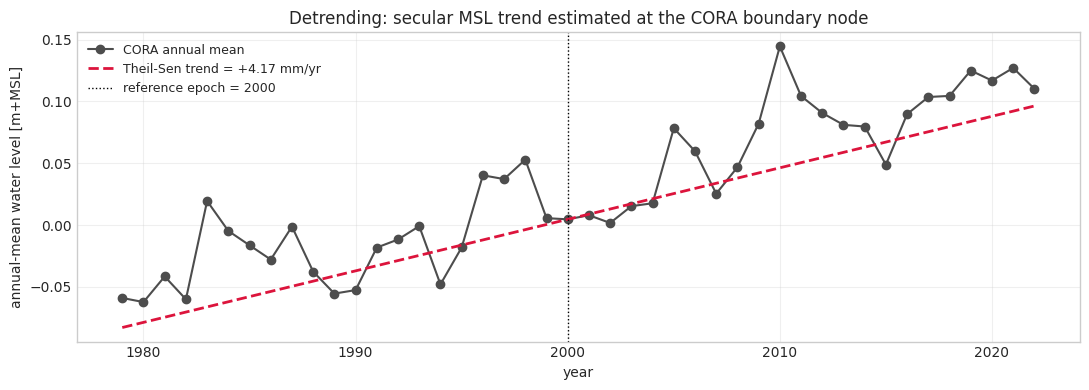

annual_mean_years_used      44.000000
minimum_hours_per_year    6574.000000
slope_m_per_year             0.004169
slope_mm_per_year            4.168667
reference_epoch_year      2000.000000
Name: detrending_parameters, dtype: float64

In [11]:
# 1) Estimate the long-term mean-sea-level trend from CORA annual means.
# Use only years with at least 75% hourly coverage so sparse years do not steer the trend.

# Collapse hourly CORA data to annual mean/count pairs for a stable MSL baseline.
annual_waterlevel = waterlevel.resample("YS").agg(["mean", "count"])
# Require roughly three quarters of a year of hourly data before trusting that annual mean.
min_annual_hours = int(0.75 * 365.25 * 24)
annual_waterlevel = annual_waterlevel[annual_waterlevel["count"] >= min_annual_hours]

# Place each annual mean near mid-year for a continuous trend coordinate.
annual_years = annual_waterlevel.index.year.to_numpy(dtype=float) + 0.5
# Use elapsed years from the first retained annual mean as the regression coordinate.
trend_t = annual_years - annual_years.min()

# Theil-Sen gives a robust slope that is less sensitive to outlier years than OLS.
msl_trend = stats.theilslopes(annual_waterlevel["mean"].to_numpy(dtype=float), trend_t, 0.95)
# Store the trend slope in meters/year; summaries also report mm/year for readability.
slope_m_per_year = float(msl_trend.slope)
# Shift the hourly record to this epoch before fitting extremes.
reference_epoch_year = float(detrend_settings["reference_epoch"])

years = annual_waterlevel.index.year.to_numpy(dtype=float)
# Anchor the displayed trend line at the reference year when that year is present.
ref_mask = annual_waterlevel.index.year == int(reference_epoch_year)
# If the reference year is missing, use the retained-period mean as a neutral display anchor.
anchor = float(annual_waterlevel.loc[ref_mask, "mean"].mean()) if ref_mask.any() else float(annual_waterlevel["mean"].mean())
trend_line = anchor + slope_m_per_year * (years - reference_epoch_year)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years, annual_waterlevel["mean"].to_numpy(dtype=float), "o-", color="0.3", label="CORA annual mean")
ax.plot(years, trend_line, "--", color="crimson", lw=2, label=f"Theil-Sen trend = {slope_m_per_year*1000:+.2f} mm/yr")
ax.axvline(reference_epoch_year, color="black", ls=":", lw=1, label=f"reference epoch = {reference_epoch_year:.0f}")
ax.set_xlabel("year")
ax.set_ylabel("annual-mean water level [m+MSL]")
ax.set_title("Detrending: secular MSL trend estimated at the CORA boundary node")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "annual_mean_years_used": len(annual_waterlevel),
    "minimum_hours_per_year": min_annual_hours,
    "slope_m_per_year": slope_m_per_year,
    "slope_mm_per_year": slope_m_per_year * 1000,
    "reference_epoch_year": reference_epoch_year,
}, name="detrending_parameters"))

### 2.2.4 Detrended Hourly Record

Shift every hourly value to the reference epoch so secular MSL rise does not inflate the POT tail.

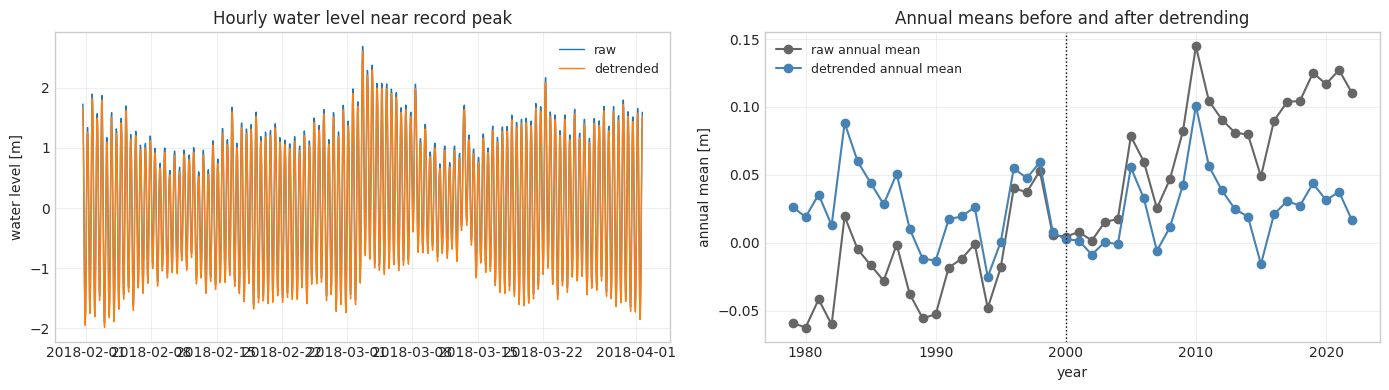

detrend_formula     H_ref(t) = H(t) - slope * (decimal_year(t) - r...
raw_mean_m                                                    0.02969
detrended_mean_m                                             0.025534
raw_max_m                                                     2.69103
detrended_max_m                                              2.615309
Name: detrended_hourly_record, dtype: object

In [12]:
# 2) Translate every hourly value to the reference epoch.
# H_ref(t) = H(t) - slope * (year(t) - reference_year).

def decimal_year(index):
    return index.year.to_numpy(dtype=float) + (index.dayofyear.to_numpy(dtype=float) - 1.0) / 365.25

# Positive offsets are years after the reference epoch; negative offsets are years before it.
year_offset = decimal_year(waterlevel.index) - reference_epoch_year
# Remove the estimated secular MSL component from each hourly value.
detrended_waterlevel = waterlevel - pd.Series(slope_m_per_year * year_offset, index=waterlevel.index)
# Recompute annual means after detrending for the before/after audit.
annual_detrended = detrended_waterlevel.resample("YS").agg(["mean", "count"])
# Apply the same coverage filter so raw and detrended annual summaries are comparable.
annual_detrended = annual_detrended[annual_detrended["count"] >= min_annual_hours]
# Keep detrending metadata with the marginal artifacts for audit/reproducibility.
detrend_meta = {
    "applied": bool(detrend_settings["enabled"]),
    "slope_m_per_year": slope_m_per_year,
    "reference_epoch_year": reference_epoch_year,
    "slope_source": detrend_settings["method"],
    "annual_mean_year_count": int(len(annual_waterlevel)),
}

# Use the raw record maximum as a compact diagnostic window for the shift.
plot_time = waterlevel.idxmax()
window_slice = (plot_time - pd.Timedelta(days=30), plot_time + pd.Timedelta(days=30))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(waterlevel.loc[window_slice[0]:window_slice[1]].index, waterlevel.loc[window_slice[0]:window_slice[1]].values, lw=1, label="raw")
axes[0].plot(detrended_waterlevel.loc[window_slice[0]:window_slice[1]].index, detrended_waterlevel.loc[window_slice[0]:window_slice[1]].values, lw=1, label="detrended")
axes[0].set_title("Hourly water level near record peak")
axes[0].set_ylabel("water level [m]")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[1].plot(annual_waterlevel.index.year, annual_waterlevel["mean"], "o-", color="0.4", label="raw annual mean")
axes[1].plot(annual_detrended.index.year, annual_detrended["mean"], "o-", color="steelblue", label="detrended annual mean")
axes[1].axvline(reference_epoch_year, color="black", ls=":", lw=1)
axes[1].set_title("Annual means before and after detrending")
axes[1].set_xlabel("year")
axes[1].set_ylabel("annual mean [m]")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "detrend_formula": "H_ref(t) = H(t) - slope * (decimal_year(t) - reference_epoch)",
    "raw_mean_m": float(waterlevel.mean()),
    "detrended_mean_m": float(detrended_waterlevel.mean()),
    "raw_max_m": float(waterlevel.max()),
    "detrended_max_m": float(detrended_waterlevel.max()),
}, name="detrended_hourly_record"))

### 2.2.5 Peaks-over-Threshold Extraction

Extract independent total-water-level peaks from the detrended hourly record and audit the threshold visually.

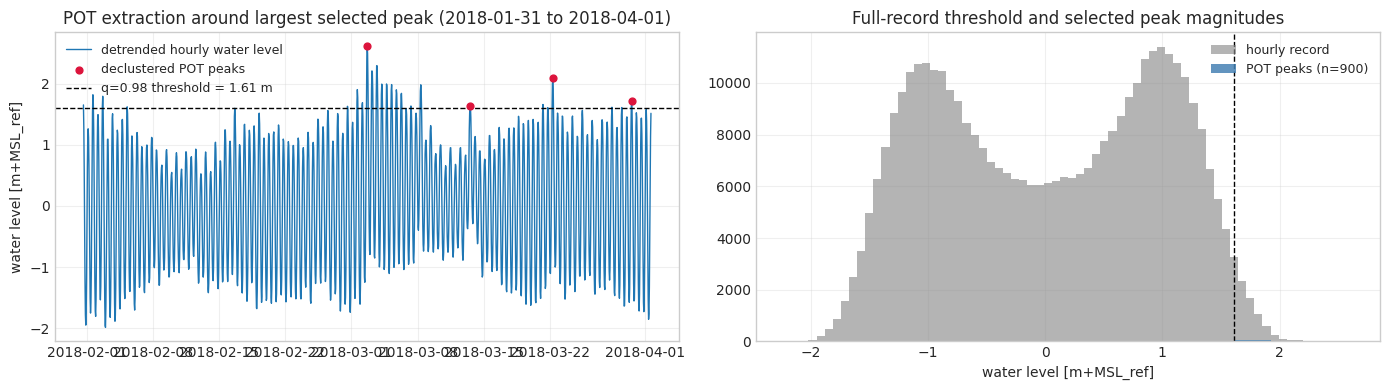

raw_threshold_m                    1.622994
detrended_threshold_m_msl_ref      1.612464
raw_peak_count                   876.000000
detrended_peak_count             900.000000
record_years                      44.000000
event_rate_per_year               20.455818
tail_region_count_rp_ge_50yr       0.000000
Name: total_water_level_pot, dtype: float64

,peak_water_level_msl_ref,event_time,threshold_m,rank,sample_rp_years,sampling_region
time,,,,,,
1979-01-01 17:00:00,1.826312,1979-01-01 17:00:00,1.612464,415,0.106017,body
1979-01-14 16:00:00,1.649284,1979-01-14 16:00:00,1.612464,807,0.054520,body
1979-01-25 13:00:00,2.330869,1979-01-25 13:00:00,1.612464,8,5.499658,body
1979-02-26 15:00:00,2.242276,1979-02-26 15:00:00,1.612464,15,2.933151,body
1979-03-26 14:00:00,1.824254,1979-03-26 14:00:00,1.612464,428,0.102797,body


In [13]:
# 3) Extract independent POT peaks from the hourly series.
# Keep raw peaks for a before/after detrending audit, then fit the marginal on detrended peaks.

# Raw threshold is retained only to compare pre/post detrending peak counts.
raw_threshold_m = float(waterlevel.quantile(pot_q))
# The detrended threshold is the actual POT threshold for the fitted marginal.
threshold_m = float(detrended_waterlevel.quantile(pot_q))
# Convert the configured declustering gap into the pyextremes time-delta form.
min_peak_distance = pd.Timedelta(hours=min_peak_distance_hours)
# Extract raw peaks only as a diagnostic companion to the detrended fit.
raw_peaks = get_extremes(
    ts=waterlevel,
    method="POT",
    threshold=raw_threshold_m,
    r=min_peak_distance,
).rename("h").sort_index()
# Extract the fitted independent peak sample from the detrended series.
historical_peaks = get_extremes(
    ts=detrended_waterlevel,
    method="POT",
    threshold=threshold_m,
    r=min_peak_distance,
).rename("h").sort_index()
detrend_meta["raw_peak_count"] = int(len(raw_peaks))
detrend_meta["detrended_peak_count"] = int(len(historical_peaks))

# Record length annualizes the POT count into an exceedance/event rate.
record_years = max((detrended_waterlevel.index.max() - detrended_waterlevel.index.min()) / pd.Timedelta(days=365.25), 1.0)
# The fitted marginal uses independent peaks per year as lambda.
event_rate_per_year = float(len(historical_peaks) / record_years)
# Keep peak magnitudes as numeric arrays for fitting and diagnostics.
peak_values = historical_peaks.to_numpy(dtype=float)
# Fit distributions to exceedances above threshold, not to absolute water levels.
peak_exceedances = (historical_peaks - threshold_m).clip(lower=0).to_numpy(dtype=float)
# Remove any non-finite values before scipy distribution fitting.
peak_exceedances = peak_exceedances[np.isfinite(peak_exceedances)]

# Build a notebook-facing member table for rank/RP summaries and later displays.
pot_members = historical_peaks.to_frame(name="peak_water_level_msl_ref").assign(
    event_time=historical_peaks.index,
    threshold_m=threshold_m,
    rank=lambda frame: frame["peak_water_level_msl_ref"].rank(method="first", ascending=False).astype(int),
)
# Empirical plotting positions: larger ranks map to shorter sample return periods.
pot_members["sample_rp_years"] = record_years / pot_members["rank"]
# Tag long-return-period peaks for quick tail/body diagnostics.
pot_members["sampling_region"] = np.where(pot_members["sample_rp_years"] >= 50, "tail", "body")

plot_time = historical_peaks.idxmax()
window_slice = (plot_time - pd.Timedelta(days=30), plot_time + pd.Timedelta(days=30))
window = detrended_waterlevel.loc[window_slice[0]:window_slice[1]]
peak_window = historical_peaks.loc[window_slice[0]:window_slice[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0, label="detrended hourly water level")
axes[0].scatter(peak_window.index, peak_window.values, color="crimson", s=24, zorder=3, label="declustered POT peaks")
axes[0].axhline(threshold_m, color="black", ls="--", lw=1.0, label=f"q={pot_q:.2f} threshold = {threshold_m:.2f} m")
axes[0].set_title(f"POT extraction around largest selected peak ({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})")
axes[0].set_ylabel("water level [m+MSL_ref]")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[1].hist(detrended_waterlevel.values, bins=70, color="0.55", alpha=0.65, label="hourly record")
axes[1].hist(historical_peaks.values, bins=35, color="steelblue", alpha=0.85, label=f"POT peaks (n={len(historical_peaks)})")
axes[1].axvline(threshold_m, color="black", ls="--", lw=1.0)
axes[1].set_title("Full-record threshold and selected peak magnitudes")
axes[1].set_xlabel("water level [m+MSL_ref]")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "raw_threshold_m": raw_threshold_m,
    "detrended_threshold_m_msl_ref": threshold_m,
    "raw_peak_count": len(raw_peaks),
    "detrended_peak_count": len(historical_peaks),
    "record_years": round(float(record_years), 2),
    "event_rate_per_year": event_rate_per_year,
    "tail_region_count_rp_ge_50yr": int((pot_members["sampling_region"] == "tail").sum()),
}, name="total_water_level_pot"))
pot_members.head()

### 2.2.6 Tail Distribution Selection

Fit exponential and GPD exceedance models above the threshold, then select the lower-AIC distribution.

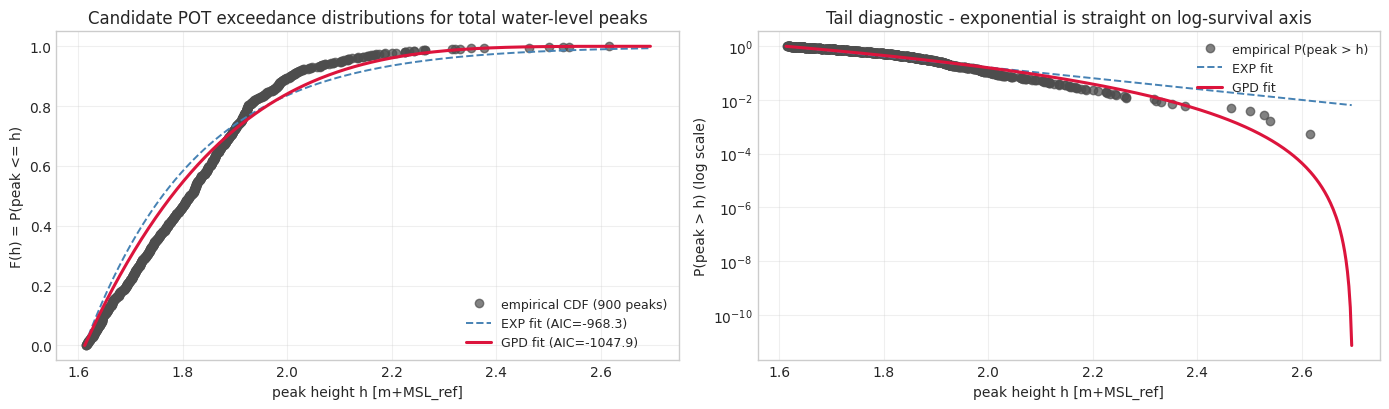

,distribution,shape,loc,scale,aic
0,gpd,-0.2403,0.0,0.2608,-1047.8514
1,exp,0.0000,0.0,0.2146,-968.2826


,value
dist,gpd
shape,-0.240278
loc,1.612464
scale,0.260785
extremes_method,pot
extremes_rate,20.455818
threshold_quantile,0.98
peak_count,900
detrend_applied,True
detrend_slope_m_per_year,0.004169


In [14]:
# 4) Fit candidate exceedance distributions above the POT threshold.
# Exponential is the simple memoryless tail; GPD allows tail shape and is the usual POT limit model.

# Force exceedance location to zero so fitted levels add back to the POT threshold cleanly.
exp_params = stats.expon.fit(peak_exceedances, floc=0)
# GPD adds a shape parameter for heavier/lighter-than-exponential tails.
gpd_params = stats.genpareto.fit(peak_exceedances, floc=0)
# Exponential has one free tail parameter when location is fixed.
exp_aic = aic(float(np.sum(stats.expon.logpdf(peak_exceedances, *exp_params))), 1)
# GPD has shape and scale, so AIC charges two free tail parameters.
gpd_aic = aic(float(np.sum(stats.genpareto.logpdf(peak_exceedances, *gpd_params))), 2)
# Keep a compact model-comparison table for the notebook and audit artifacts.
aic_table = pd.DataFrame([
    {"distribution": "exp", "shape": 0.0, "loc": float(exp_params[0]), "scale": float(exp_params[1]), "aic": exp_aic},
    {"distribution": "gpd", "shape": float(gpd_params[0]), "loc": float(gpd_params[1]), "scale": float(gpd_params[2]), "aic": gpd_aic},
]).sort_values("aic").reset_index(drop=True)
# The lower-AIC model becomes the marginal used for return levels.
selected_distribution = str(aic_table.loc[0, "distribution"])
# Convert exceedance-distribution parameters back to absolute water-level parameters.
if selected_distribution == "exp":
    selected_params = (0.0, threshold_m + float(exp_params[0]), float(exp_params[1]))
else:
    selected_params = (float(gpd_params[0]), threshold_m + float(gpd_params[1]), float(gpd_params[2]))

# Wrap distribution, parameters, and annual event rate in the shared marginal helper.
marginal = HistoricalPeakMarginal(
    dist_name=selected_distribution,
    params=selected_params,
    extremes_rate=event_rate_per_year,
    method=extremes_policy["method"],
    threshold_quantile=pot_q,
    peak_count=len(historical_peaks),
)

# Sorted exceedances support empirical CDF/survival diagnostics.
sorted_excess = np.sort(peak_exceedances)
# Evaluate fitted curves over the observed exceedance range with a small upper margin.
grid = np.linspace(0, max(sorted_excess.max() * 1.08, 1e-6), 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(sorted_excess + threshold_m, np.linspace(0, 1, len(sorted_excess)), "o", color="0.3", alpha=0.7, label=f"empirical CDF ({len(sorted_excess):,} peaks)")
axes[0].plot(grid + threshold_m, stats.expon.cdf(grid, *exp_params), "--", color="steelblue", lw=1.4, label=f"EXP fit (AIC={exp_aic:.1f})")
axes[0].plot(grid + threshold_m, stats.genpareto.cdf(grid, *gpd_params), "-", color="crimson", lw=2.2, label=f"GPD fit (AIC={gpd_aic:.1f})")
axes[0].set_xlabel("peak height h [m+MSL_ref]")
axes[0].set_ylabel("F(h) = P(peak <= h)")
axes[0].set_title("Candidate POT exceedance distributions for total water-level peaks")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plotting-position survival curve for visual tail comparison.
n = len(sorted_excess)
emp_surv = 1.0 - (np.arange(1, n + 1) - 0.5) / n
axes[1].semilogy(sorted_excess + threshold_m, emp_surv, "o", color="0.3", alpha=0.7, label="empirical P(peak > h)")
axes[1].semilogy(grid + threshold_m, stats.expon.sf(grid, *exp_params), "--", color="steelblue", lw=1.4, label="EXP fit")
axes[1].semilogy(grid + threshold_m, stats.genpareto.sf(grid, *gpd_params), "-", color="crimson", lw=2.2, label="GPD fit")
axes[1].set_xlabel("peak height h [m+MSL_ref]")
axes[1].set_ylabel("P(peak > h) (log scale)")
axes[1].set_title("Tail diagnostic - exponential is straight on log-survival axis")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

display(aic_table.round(4))
display(marginal_params_frame(marginal, detrend_meta).T.rename(columns={"h": "value"}))

### 2.2.7 Bootstrap Return-Period Curve

Resample threshold exceedances, refit the tail model, and plot the return-period curve with uncertainty.

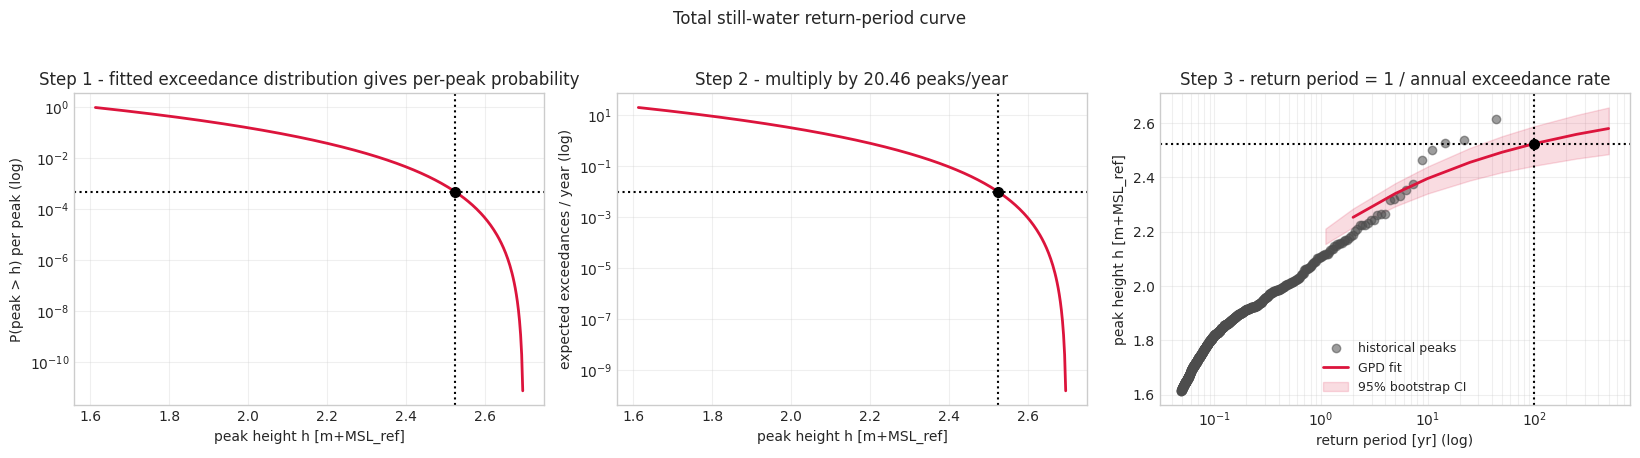

,h_point,h_lo,h_median,h_hi
rps,,,,
1.1,2.1842,2.1543,2.1830,2.2111
2.0,2.2529,2.2165,2.2512,2.2852
5.0,2.3408,2.2938,2.3388,2.3790
10.0,2.3956,2.3404,2.3931,2.4399
25.0,2.4553,2.3885,2.4523,2.5084
50.0,2.4925,2.4190,2.4898,2.5514
100.0,2.5240,2.4427,2.5208,2.5880
250.0,2.5584,2.4691,2.5547,2.6296
500.0,2.5798,2.4853,2.5757,2.6571


bootstrap_replicates                                1000
bootstrap_succeeded                                 1000
selected_distribution                                gpd
bootstrap_distribution_counts    {'exp': 0, 'gpd': 1000}
Name: return_period_bootstrap, dtype: object

In [15]:
# 5) Bootstrap the exceedance sample to quantify return-period uncertainty.
# Each replicate resamples exceedances, refits both candidate distributions, reselects by AIC,
# and keeps the POT threshold and event rate fixed for a clean marginal uncertainty band.

# Seeded RNG makes bootstrap intervals reproducible across notebook runs.
rng = np.random.default_rng(int(bootstrap_settings["seed"]))
# Bootstrap the exact return periods displayed and written downstream.
bootstrap_rps = np.asarray(fit_rps, dtype=float)
# Preallocate one row per replicate and one column per return period.
bootstrap_values = np.full((int(bootstrap_settings["n_replicates"]), len(bootstrap_rps)), np.nan, dtype=float)
# Track how often each model wins during resampled AIC selection.
bootstrap_distribution_counts = {"exp": 0, "gpd": 0}
# Resample exceedances with replacement; keep threshold and annual event rate fixed.
for replicate in range(int(bootstrap_settings["n_replicates"])):
    sample = peak_exceedances[rng.integers(0, len(peak_exceedances), size=len(peak_exceedances))]
    try:
        sample_exp = stats.expon.fit(sample, floc=0)
        sample_gpd = stats.genpareto.fit(sample, floc=0)
        sample_exp_aic = aic(float(np.sum(stats.expon.logpdf(sample, *sample_exp))), 1)
        sample_gpd_aic = aic(float(np.sum(stats.genpareto.logpdf(sample, *sample_gpd))), 2)
        # Convert return period to per-peak survival probability: S = 1 / (T * lambda).
        q = np.clip(1.0 / (bootstrap_rps * event_rate_per_year), 1e-9, 1 - 1e-9)
        if sample_exp_aic <= sample_gpd_aic:
            bootstrap_distribution_counts["exp"] += 1
            bootstrap_values[replicate] = threshold_m + stats.expon.isf(q, *sample_exp)
        else:
            bootstrap_distribution_counts["gpd"] += 1
            bootstrap_values[replicate] = threshold_m + stats.genpareto.isf(q, *sample_gpd)
    except Exception:
        continue
# Drop failed/non-finite replicates before quantile summaries.
valid_bootstrap = bootstrap_values[np.all(np.isfinite(bootstrap_values), axis=1)]
# Two-sided interval alpha from the configured confidence level.
alpha = 1.0 - float(bootstrap_settings["confidence_level"])
# Leave bootstrap as None if every replicate fails.
bootstrap = None
if len(valid_bootstrap):
    bootstrap = {
        "rps": bootstrap_rps,
        "lo": np.quantile(valid_bootstrap, alpha / 2.0, axis=0),
        "median": np.quantile(valid_bootstrap, 0.5, axis=0),
        "hi": np.quantile(valid_bootstrap, 1.0 - alpha / 2.0, axis=0),
        "confidence_level": float(bootstrap_settings["confidence_level"]),
        "n_replicates": int(bootstrap_settings["n_replicates"]),
        "n_succeeded": int(len(valid_bootstrap)),
        "distribution_counts": bootstrap_distribution_counts,
    }

# Main return-period axis excludes the extra near-annual point used for fitting summaries.
rp_values = np.asarray(extremes_policy["return_periods"], dtype=float)
# Convert exceedance grid back to absolute peak heights.
q_grid = grid + threshold_m
# Annual exceedance rate = per-peak survival times the independent peak rate.
if selected_distribution == "exp":
    annual_exceedance = event_rate_per_year * stats.expon.sf(grid, *exp_params)
else:
    annual_exceedance = event_rate_per_year * stats.genpareto.sf(grid, *gpd_params)
# Return period is the reciprocal of annual exceedance rate.
rp_at_h = 1.0 / np.clip(annual_exceedance, 1e-12, None)
# Keep the per-peak probability visible beside the annualized curve.
per_peak_survival_at_h = annual_exceedance / event_rate_per_year
# Use a 100-year marker to tie survival, annual rate, and return level together.
highlight_rp = 100.0
highlight_h = float(marginal.magnitude(highlight_rp))
highlight_excess = max(highlight_h - threshold_m, 0.0)
if selected_distribution == "exp":
    highlight_per_peak_survival = float(stats.expon.sf(highlight_excess, *exp_params))
else:
    highlight_per_peak_survival = float(stats.genpareto.sf(highlight_excess, *gpd_params))
highlight_annual_rate = 1.0 / highlight_rp
# Sort observed peaks from low to high for empirical return-period plotting positions.
observed = pot_members.sort_values("peak_water_level_msl_ref", ascending=True).copy()
observed["observed_rp_years"] = record_years / np.arange(len(observed), 0, -1)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
axes[0].semilogy(q_grid, per_peak_survival_at_h, "-", color="crimson", lw=2)
axes[0].axvline(highlight_h, ls=":", color="black")
axes[0].axhline(highlight_per_peak_survival, ls=":", color="black")
axes[0].plot([highlight_h], [highlight_per_peak_survival], "o", color="black", ms=7)
axes[0].set_xlabel("peak height h [m+MSL_ref]")
axes[0].set_ylabel("P(peak > h) per peak (log)")
axes[0].set_title("Step 1 - fitted exceedance distribution gives per-peak probability")
axes[0].grid(True, alpha=0.3, which="both")

axes[1].semilogy(q_grid, annual_exceedance, "-", color="crimson", lw=2)
axes[1].axvline(highlight_h, ls=":", color="black")
axes[1].axhline(highlight_annual_rate, ls=":", color="black")
axes[1].plot([highlight_h], [highlight_annual_rate], "o", color="black", ms=7)
axes[1].set_xlabel("peak height h [m+MSL_ref]")
axes[1].set_ylabel("expected exceedances / year (log)")
axes[1].set_title(f"Step 2 - multiply by {event_rate_per_year:.2f} peaks/year")
axes[1].grid(True, alpha=0.3, which="both")

axes[2].plot(observed["observed_rp_years"], observed["peak_water_level_msl_ref"], "o", color="0.3", alpha=0.55, label="historical peaks")
axes[2].plot(rp_values, marginal.magnitude(rp_values), "-", color="crimson", lw=2, label=f"{selected_distribution.upper()} fit")
if bootstrap is not None:
    cl_pct = int(round(100 * bootstrap["confidence_level"]))
    axes[2].fill_between(bootstrap["rps"], bootstrap["lo"], bootstrap["hi"], color="crimson", alpha=0.15, label=f"{cl_pct}% bootstrap CI")
axes[2].axvline(highlight_rp, ls=":", color="black")
axes[2].axhline(highlight_h, ls=":", color="black")
axes[2].plot([highlight_rp], [highlight_h], "o", color="black", ms=7)
axes[2].set_xscale("log")
axes[2].set_xlabel("return period [yr] (log)")
axes[2].set_ylabel("peak height h [m+MSL_ref]")
axes[2].set_title("Step 3 - return period = 1 / annual exceedance rate")
axes[2].legend(loc="best", fontsize=9)
axes[2].grid(True, alpha=0.3, which="both")
fig.suptitle("Total still-water return-period curve", y=1.03)
fig.tight_layout()
plt.show()

# Combine point estimates and bootstrap interval columns into one display/write-ready table.
return_period_table = pd.concat([
    marginal_rps_frame(marginal, fit_rps).rename(columns={"h": "h_point"}),
    pd.DataFrame({"h_lo": bootstrap["lo"], "h_median": bootstrap["median"], "h_hi": bootstrap["hi"]}, index=pd.Index(fit_rps, name="rps"))
    if bootstrap is not None else pd.DataFrame(index=pd.Index(fit_rps, name="rps")),
], axis=1).round(4)
display(return_period_table)
display(pd.Series({
    "bootstrap_replicates": int(bootstrap_settings["n_replicates"]),
    "bootstrap_succeeded": 0 if bootstrap is None else bootstrap["n_succeeded"],
    "selected_distribution": selected_distribution,
    "bootstrap_distribution_counts": bootstrap_distribution_counts,
}, name="return_period_bootstrap"))

### 2.2.8 Stationarity Diagnostic on Detrended Peaks

Check whether the selected POT peaks still show residual time structure after detrending.

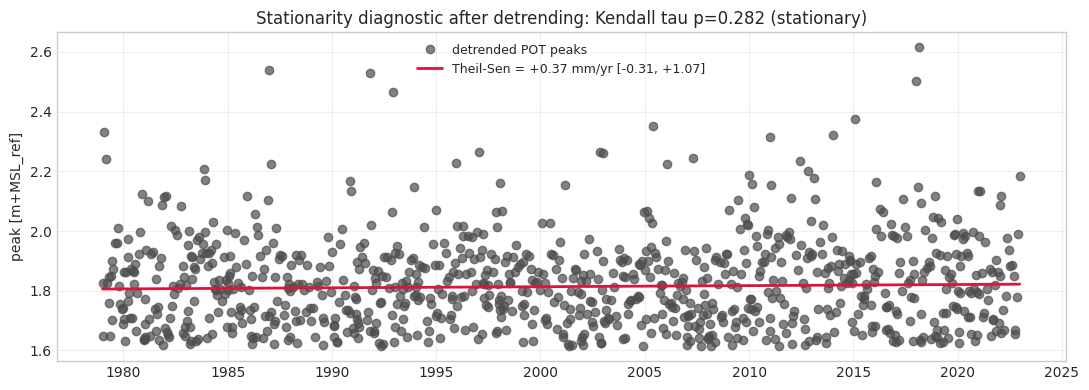

n_peaks                               900
mann_kendall_tau                 0.023977
mann_kendall_p                   0.281533
theil_sen_slope_mm_per_year       0.36634
ols_slope_mm_per_year            0.492457
interpretation                 stationary
Name: stationarity_after_detrend, dtype: object

In [16]:
# 6) Check whether the detrended POT peaks still show a monotonic trend.
# Kendall tau tests rank trend; Theil-Sen and OLS report slope magnitudes for the audit table.

# Express peak times as years since the first selected peak for trend diagnostics.
peak_t_years = ((historical_peaks.index - historical_peaks.index.min()) / pd.Timedelta(days=365.25)).to_numpy(dtype=float)
# Kendall tau tests monotonic association without assuming linear residuals.
mk = stats.kendalltau(peak_t_years, peak_values)
# Theil-Sen gives a robust slope and confidence bounds for the peak series.
peak_trend = stats.theilslopes(peak_values, peak_t_years, 0.95)
# OLS slope is kept as secondary diagnostic.
peak_ols = stats.linregress(peak_t_years, peak_values)
# Package diagnostic values
stationarity = {
    "n_peaks": int(len(historical_peaks)),
    "record_start": str(historical_peaks.index.min().date()),
    "record_end": str(historical_peaks.index.max().date()),
    "record_years": float(peak_t_years.max()),
    "mann_kendall_tau": float(mk.statistic),
    "mann_kendall_p": float(mk.pvalue),
    "theil_sen_slope_m_per_year": float(peak_trend.slope),
    "theil_sen_lo_m_per_year": float(peak_trend.low_slope),
    "theil_sen_hi_m_per_year": float(peak_trend.high_slope),
    "ols_slope_m_per_year": float(peak_ols.slope),
    "ols_p": float(peak_ols.pvalue),
    "detrend": detrend_meta,
}

# Endpoints for drawing the fitted Theil-Sen diagnostic line.
line_t = np.array([peak_t_years.min(), peak_t_years.max()])
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(historical_peaks.index, peak_values, "o", color="0.3", alpha=0.7, label="detrended POT peaks")
ax.plot(
    [historical_peaks.index.min(), historical_peaks.index.max()],
    peak_trend.intercept + peak_trend.slope * line_t,
    "-",
    color="crimson",
    lw=2,
    label=(
        f"Theil-Sen = {peak_trend.slope*1000:+.2f} mm/yr "
        f"[{peak_trend.low_slope*1000:+.2f}, {peak_trend.high_slope*1000:+.2f}]"
    ),
)
# Treat p < 0.05 as evidence that one stationary marginal may need review.
note = "stationary" if stationarity["mann_kendall_p"] >= 0.05 else "trend detected"
ax.set_title(f"Stationarity diagnostic after detrending: Kendall tau p={stationarity['mann_kendall_p']:.3f} ({note})")
ax.set_ylabel("peak [m+MSL_ref]")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "n_peaks": stationarity["n_peaks"],
    "mann_kendall_tau": stationarity["mann_kendall_tau"],
    "mann_kendall_p": stationarity["mann_kendall_p"],
    "theil_sen_slope_mm_per_year": stationarity["theil_sen_slope_m_per_year"] * 1000,
    "ols_slope_mm_per_year": stationarity["ols_slope_m_per_year"] * 1000,
    "interpretation": note,
}, name="stationarity_after_detrend"))

### 2.2.9 Persist Total-Water Marginal Artifacts

Write the fitted peaks, marginal parameters, return-period tables, bootstrap metadata, and stationarity report for downstream catalog stages.

In [17]:
# 7) Persist the same artifacts downstream stages expect

# Ensure the catalog directory exists before writing marginal artifacts.
paths["catalog_root"].mkdir(parents=True, exist_ok=True)
# detrended independent peak sample used for the fit.
historical_peaks.rename_axis("time").to_frame().to_csv(paths["historical_peaks_csv"])
# selected distribution parameters plus detrending metadata.
marginal_params_frame(marginal, detrend_meta).to_csv(paths["marginal_params_csv"])
# point return levels for downstream summaries.
marginal_rps_frame(marginal, fit_rps).round(4).to_csv(paths["marginal_rps_csv"])
# the residual-trend diagnostic for audit review.
paths["stationarity_report_json"].write_text(json.dumps(stationarity, indent=2), encoding="utf-8")
# Bootstrap artifacts are optional because the fit can still proceed without valid replicates.
if bootstrap is not None:
    pd.DataFrame({
        "h_point": marginal.magnitude(fit_rps),
        "h_lo": bootstrap["lo"],
        "h_median": bootstrap["median"],
        "h_hi": bootstrap["hi"],
    }, index=pd.Index(fit_rps, name="rps")).round(4).to_csv(paths["marginal_rps_ci_csv"])
    paths["marginal_bootstrap_json"].write_text(json.dumps({
        "confidence_level": bootstrap["confidence_level"],
        "n_replicates": bootstrap["n_replicates"],
        "n_succeeded": bootstrap["n_succeeded"],
        "distribution_counts": bootstrap["distribution_counts"],
    }, indent=2), encoding="utf-8")

# Keep in-memory artifacts available for later notebook cells.
catalog_artifacts = {"bootstrap": bootstrap, "stationarity": stationarity}

display(pd.Series({
    "historical_peaks_csv": str(paths["historical_peaks_csv"]),
    "marginal_params_csv": str(paths["marginal_params_csv"]),
    "marginal_rps_csv": str(paths["marginal_rps_csv"]),
    "marginal_rps_ci_csv": str(paths["marginal_rps_ci_csv"]),
    "stationarity_report_json": str(paths["stationarity_report_json"]),
    "selected_tail_distribution": selected_distribution,
}, name="total_water_level_artifacts"))

historical_peaks_csv          /home/grahamhults/projects/Flood-RM/locations/...
marginal_params_csv           /home/grahamhults/projects/Flood-RM/locations/...
marginal_rps_csv              /home/grahamhults/projects/Flood-RM/locations/...
marginal_rps_ci_csv           /home/grahamhults/projects/Flood-RM/locations/...
stationarity_report_json      /home/grahamhults/projects/Flood-RM/locations/...
selected_tail_distribution                                                  gpd
Name: total_water_level_artifacts, dtype: str

### 2.2.10 Non-Tidal Residual - Coastal Copula Axis

Split CORA total water level into mean sea level, astronomical tide, and non-tidal residual (NTR). The copula uses NTR + rainfall; the realization later rebuilds `MSL + tide + K * NTR`, so the tide is preserved rather than scaled.


#### Coastal dependence policy

Keep the stakeholder-facing site knobs here. The reusable policy shape, source paths, and schemas are assembled in `src` from the runtime config.


In [18]:
# Site knobs for the UTide solve and storm-season population filter.
coastal_latitude = 42.1
storm_centroid = (-70.7, 42.1)

dependence_policy = configure_coastal_dependence_policy(
    config,
    paths,
    coastal_latitude=coastal_latitude,
    storm_centroid=storm_centroid,
)
ntr_member_policy = dependence_policy["member_libraries"]["coastal_water_level"]
ntr_target_rate_per_year = float(ntr_member_policy["target_rate_per_year"])
ntr_min_separation_hours = float(ntr_member_policy["decluster_window_hours"])

display(pd.Series({
    "dependence_method": dependence_policy["method"],
    "driver_vector": ", ".join(dependence_policy["driver_vector"]),
    "coastal_transform": dependence_policy["driver_records"]["coastal_water_level"]["transform"],
    "tide_engine": "UTide via coastal_components",
    "coastal_latitude": coastal_latitude,
    "storm_centroid_lon_lat": storm_centroid,
    "ntr_target_rate_per_year": ntr_target_rate_per_year,
    "ntr_declustering_hours": ntr_min_separation_hours,
    "rainfall_record": dependence_policy["driver_records"]["rainfall"]["path"],
}, name="coastal_dependence_policy"))

dependence_method                                                copula_joint
driver_vector                                   coastal_water_level, rainfall
coastal_transform                                                         ntr
tide_engine                                      UTide via coastal_components
coastal_latitude                                                         42.1
storm_centroid_lon_lat                                          (-70.7, 42.1)
ntr_target_rate_per_year                                                  5.0
ntr_declustering_hours                                                  120.0
rainfall_record             data/sources/aorc_sst/marshfield/72hr-events/s...
Name: coastal_dependence_policy, dtype: object

#### UTide tide/NTR decomposition

`coastal_components` estimates a 30-day mean sea level, reconstructs the astronomical tide with UTide, and defines NTR as the remaining meteorological residual.


In [19]:
# NTR is computed from the CORA total-water-level record; the CORA CSV is not modified.
components = coastal_components(waterlevel, latitude=coastal_latitude)
ntr_series = components["ntr"].dropna().sort_index()

display(pd.Series({
    "component_rows": len(components),
    "component_start": components.index.min(),
    "component_end": components.index.max(),
    "ntr_mean_m": float(ntr_series.mean()),
    "ntr_std_m": float(ntr_series.std()),
    "ntr_max_m": float(ntr_series.max()),
}, name="ntr_decomposition_summary"))


component_rows                  385681
component_start    1979-01-01 00:00:00
component_end      2022-12-31 00:00:00
ntr_mean_m                         0.0
ntr_std_m                     0.117033
ntr_max_m                      1.27432
Name: ntr_decomposition_summary, dtype: object

#### NTR POT marginal

Choose an independent-peak threshold that yields about five NTR events per year, then fit the POT marginal used by the coastal copula axis.


In [20]:
# Estimate the record length after the centered MSL window trims edge hours.
ntr_record_years = (ntr_series.index[-1] - ntr_series.index[0]).total_seconds() / (365.25 * 86400.0)
ntr_target_peak_count = max(1, int(round(ntr_target_rate_per_year * ntr_record_years)))
ntr_separation = pd.Timedelta(hours=ntr_min_separation_hours)

# Pick the smallest value among the largest independent NTR peaks needed for the target rate.
ntr_candidate_values = ntr_series[ntr_series > ntr_series.quantile(0.90)].sort_values(ascending=False, kind="stable")
ntr_selected_times = []
ntr_selected_values = []
for event_time, value in ntr_candidate_values.items():
    if all(abs(event_time - chosen_time) >= ntr_separation for chosen_time in ntr_selected_times):
        ntr_selected_times.append(event_time)
        ntr_selected_values.append(float(value))
        if len(ntr_selected_values) >= ntr_target_peak_count:
            break
if not ntr_selected_values:
    raise ValueError("No independent NTR peaks found for threshold selection")

# pyextremes performs the final POT extraction with the selected threshold and declustering window.
ntr_threshold_m = ntr_selected_values[-1]
ntr_extremes = get_extremes(
    ts=ntr_series,
    method="POT",
    threshold=ntr_threshold_m,
    r=ntr_separation,
)
ntr_peaks = ntr_extremes.rename("value").to_frame().rename_axis("time").reset_index()
ntr_rate = len(ntr_peaks) / ntr_record_years
ntr_marginal = fit_index_marginal(ntr_peaks["value"].to_numpy(), event_rate=ntr_rate, kind="pot")

ntr_return_levels = pd.DataFrame({
    "return_period_years": fit_rps,
    "ntr_return_level_m": ntr_marginal.magnitude(fit_rps),
})
display(ntr_return_levels.round({"return_period_years": 2, "ntr_return_level_m": 3}))
display(pd.Series({
    "ntr_threshold_m": ntr_threshold_m,
    "ntr_peak_count": len(ntr_peaks),
    "ntr_rate_per_year": ntr_rate,
    "ntr_target_rate_per_year": ntr_target_rate_per_year,
    "ntr_record_years": ntr_record_years,
    "ntr_min_separation_hours": ntr_min_separation_hours,
}, name="ntr_pot_policy"))


,return_period_years,ntr_return_level_m
0,1.1,0.683
1,2.0,0.769
2,5.0,0.901
3,10.0,1.001
4,25.0,1.133
5,50.0,1.232
6,100.0,1.332
7,250.0,1.464
8,500.0,1.564


ntr_threshold_m               0.441256
ntr_peak_count              213.000000
ntr_rate_per_year             4.841210
ntr_target_rate_per_year      5.000000
ntr_record_years             43.997262
ntr_min_separation_hours    120.000000
Name: ntr_pot_policy, dtype: float64

#### Decomposition diagnostic

Inspect the largest NTR event to confirm the copula driver is meteorological residual, while the total boundary water level still retains tide and mean sea level.


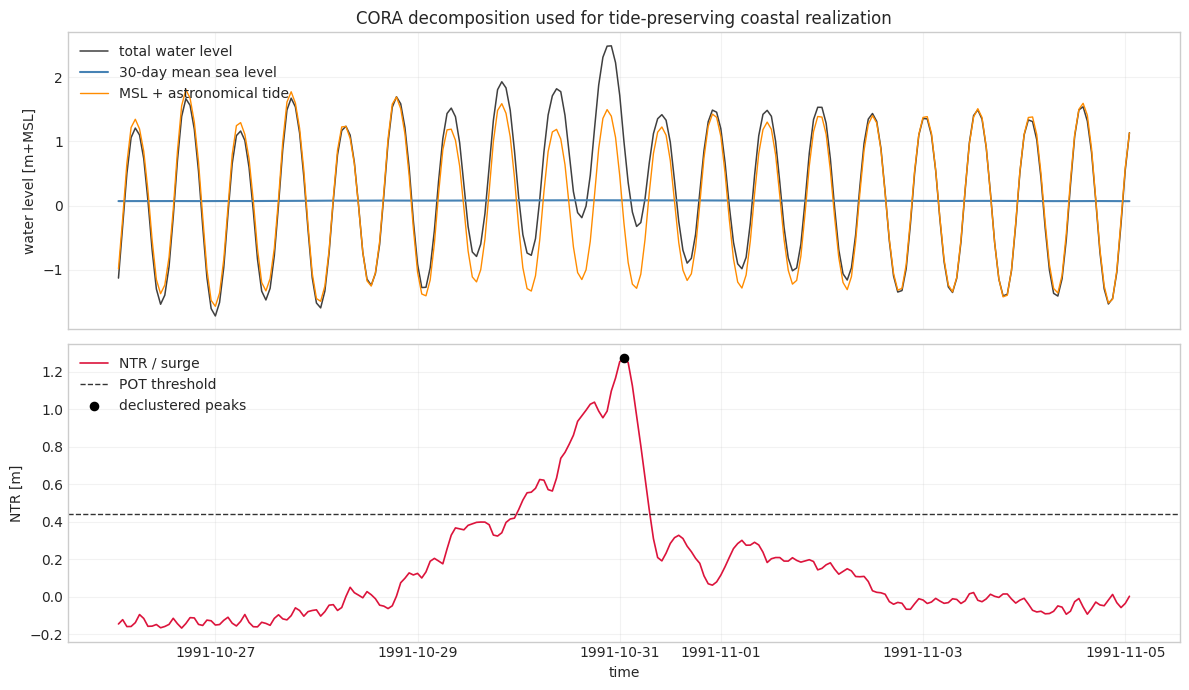

In [21]:
plot_time = pd.Timestamp(ntr_peaks.loc[ntr_peaks["value"].idxmax(), "time"])
window_slice = (plot_time - pd.Timedelta(days=5), plot_time + pd.Timedelta(days=5))
component_window = components.loc[window_slice[0]:window_slice[1]]
ntr_peak_window = ntr_peaks[
    (ntr_peaks["time"] >= window_slice[0]) & (ntr_peaks["time"] <= window_slice[1])
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(component_window.index, component_window["wl"], label="total water level", color="0.25", lw=1.1)
axes[0].plot(component_window.index, component_window["msl"], label="30-day mean sea level", color="steelblue", lw=1.5)
axes[0].plot(component_window.index, component_window["msl"] + component_window["tide"], label="MSL + astronomical tide", color="darkorange", lw=1.0)
axes[0].set_ylabel("water level [m+MSL]")
axes[0].set_title("CORA decomposition used for tide-preserving coastal realization")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.25)

axes[1].plot(component_window.index, component_window["ntr"], label="NTR / surge", color="crimson", lw=1.2)
axes[1].axhline(ntr_threshold_m, color="0.2", ls="--", lw=1.0, label="POT threshold")
axes[1].scatter(ntr_peak_window["time"], ntr_peak_window["value"], s=35, color="black", zorder=3, label="declustered peaks")
axes[1].set_ylabel("NTR [m]")
axes[1].set_xlabel("time")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()


## Stage 3 — Per-storm-type copula-joint compound dependence

Assemble the two-sided POT co-occurrence sample over the non-tidal residual (surge) + rainfall drivers. Tag each historical event by storm-type population from HURDAT2 proximity and season, fit a separate vine copula per population, and combine their annual exceedance frequencies.

- Co-occurrence window: ±72 hours between NTR and rainfall events.
- Population model: TC, nor'easter, and other non-tropical populations get separate dependence fits when enough events exist.
- Combined AND return period: `T = 1 / sum_p(lambda_p * S_p(x))`, summing population-specific joint exceedance frequencies.
- Historical driver-severity plot: observed paired drivers are binned by empirical AND return period before any synthetic design set is shown.
- Stress/training selection: synthetic driver pairs are sampled and the configured 500-event set is selected by severity fractions.

### 3.1 Historical paired-driver severity

Pair observed NTR and rainfall events, classify storm population, and show the historical AND-return-period distribution before sampling synthetic design events.


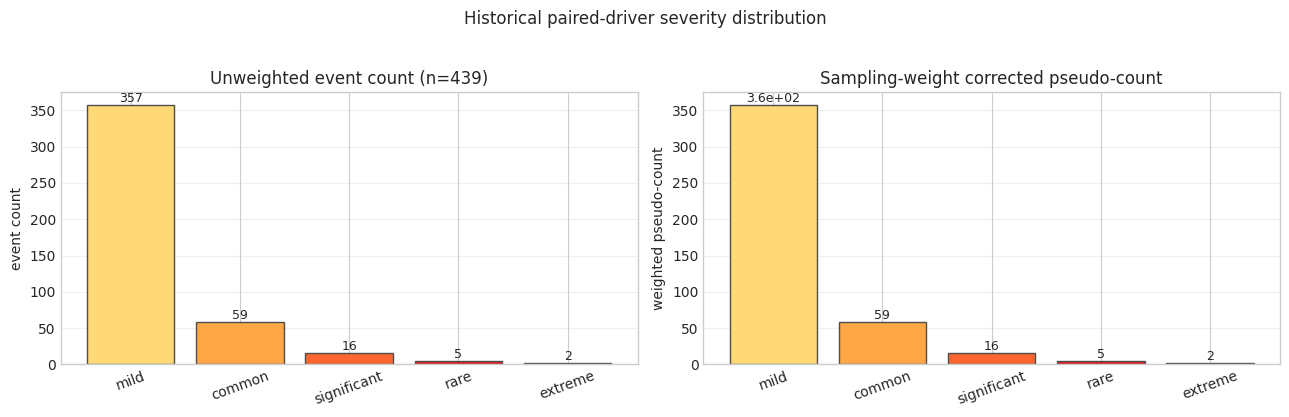

historical_paired_events                                                             439
driver_vector                                              coastal_water_level, rainfall
cooccurrence_window_hours                                                           72.0
decluster_window_hours                                                             120.0
threshold_selection                    target_rate_per_year for each conditioning driver
target_distinct_storm_rate_per_year                                                  5.0
severity_basis                                 empirical paired-driver AND return period
median_historical_driver_rp_years                                               0.540899
max_historical_driver_rp_years                                                113.383732
Name: historical_driver_severity, dtype: object

In [22]:
# observed co-occurring NTR + rainfall sample for the coastal copula.
joint_paired = assemble_paired_observations_from_config(config, location_root=location_root)
joint_paired = joint_paired.assign(
    storm_type=classify_from_config(joint_paired["event_time"], config, tracks_path=paths["hurdat2_tracks_csv"])
)
joint_driver_vector = config["event_catalog"]["dependence"]["driver_vector"]

historical_driver_u = np.column_stack([
    joint_paired[driver].rank(method="average").to_numpy(dtype=float) / (len(joint_paired) + 1)
    for driver in joint_driver_vector
])
historical_driver_survival = np.clip(np.prod(1 - historical_driver_u, axis=1), 1e-12, None)
historical_driver_rate = float(joint_paired.attrs.get("base_event_rate_per_year", dependence_policy.get("event_rate_per_year", 5.0)))
historical_driver_severity = joint_paired.copy()
historical_driver_severity["sample_rp_years"] = 1.0 / np.clip(historical_driver_rate * historical_driver_survival, 1e-12, None)
historical_driver_severity["severity_band"] = assign_severity_bands(
    historical_driver_severity["sample_rp_years"],
    config["sampling"]["severity_bands"],
)
historical_driver_severity["sampling_weight"] = 1.0

fig = P.plot_severity_bands(historical_driver_severity)
fig.suptitle("Historical paired-driver severity distribution", y=1.03)
plt.show()

display(pd.Series({
    "historical_paired_events": len(historical_driver_severity),
    "driver_vector": ", ".join(joint_driver_vector),
    "cooccurrence_window_hours": dependence_policy["cooccurrence"]["pairing_window_hours"],
    "decluster_window_hours": dependence_policy["cooccurrence"]["decluster_window_hours"],
    "threshold_selection": "target_rate_per_year for each conditioning driver",
    "target_distinct_storm_rate_per_year": dependence_policy["cooccurrence"]["target_rate_per_year"],
    "severity_basis": "empirical paired-driver AND return period",
    "median_historical_driver_rp_years": float(np.nanmedian(historical_driver_severity["sample_rp_years"])),
    "max_historical_driver_rp_years": float(np.nanmax(historical_driver_severity["sample_rp_years"])),
}, name="historical_driver_severity"))


### 3.2 Fit coastal joint catalog

Fit the per-storm-type copula mixture, realize observed forcing analogs, write the historical-tail reference catalog, and show compact diagnostics.


copula_engine                                                         pyvinecopulib
candidate_pool_count                                                         100000
target_event_count                                                              500
benchmark_return_periods                                         [10, 50, 100, 500]
severity_band_fractions           {'mild': 0.05, 'common': 0.2, 'significant': 0...
storm_type_populations_enabled                                                 True
compound_pairing_strategy                 operationally_severe_plausible_dependence
Name: copula_sampling_parameters, dtype: object

realized base rate 8.93/yr (threshold calibrated to 5/yr over 44 yr)


,storm_type,n_events,rate,fitted,low_confidence
0,nor_easter,315,6.406181,True,False
1,other_non_tropical,115,2.338764,True,False
2,tc,9,0.183034,True,True


,severity_band,catalog_count,distinct_support,stress_budget_count,meets_budget,low_support_flag
0,mild,25,25,25,True,False
1,common,100,100,100,True,False
2,significant,100,100,100,True,False
3,rare,125,125,125,True,False
4,extreme,150,150,150,True,False
5,beyond_design,0,0,0,True,False


paired_observation_rows                                                      439
copula_joint_catalog_rows                                                    500
historical_tail_rows                                                          10
scenario_handoff_rows                                                        510
driver_vector                                      coastal_water_level, rainfall
storm_type_populations              nor_easter:315, other_non_tropical:115, tc:9
mixture_total_rate_per_year                                                 8.93
forcing_pairing_policy                                              copula_joint
stress_budget_met                                                           True
historical_tail_csv            /home/grahamhults/projects/Flood-RM/locations/...
Name: copula_joint_summary, dtype: object

storm_type_population_report_csv    /home/grahamhults/projects/Flood-RM/locations/...
Name: copula_fit_provenance, dtype: str

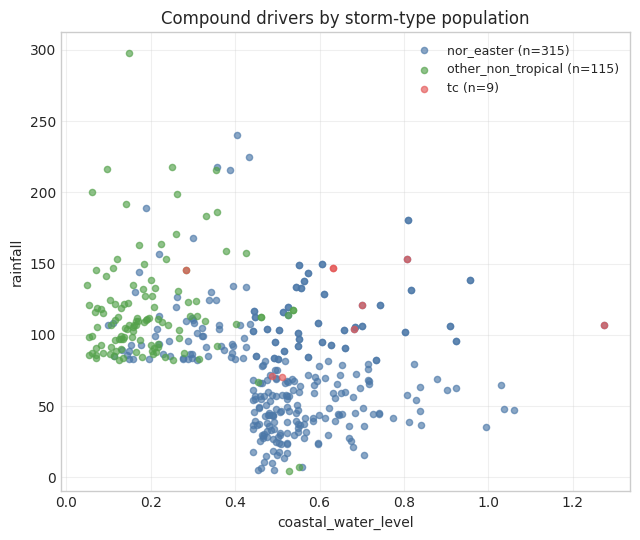

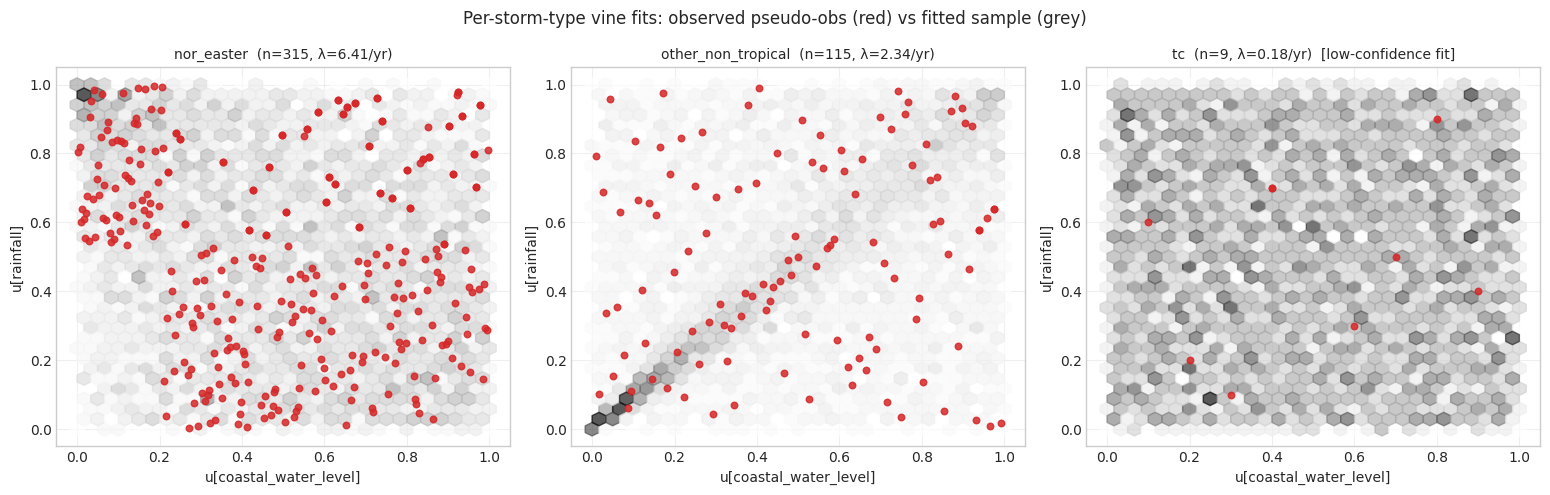

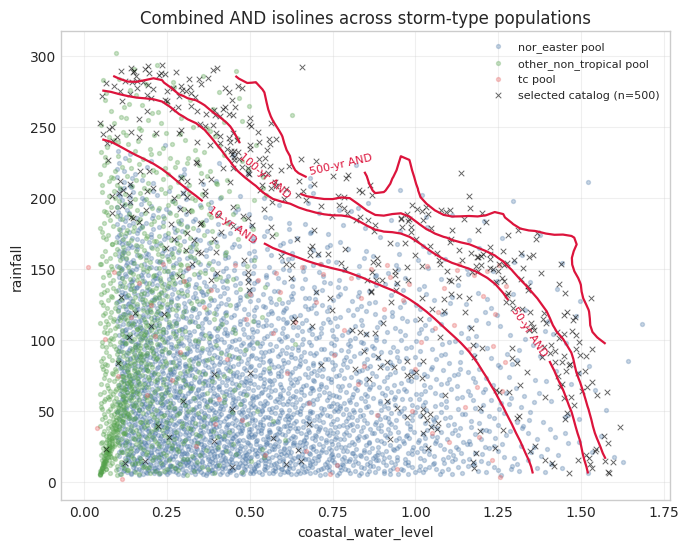

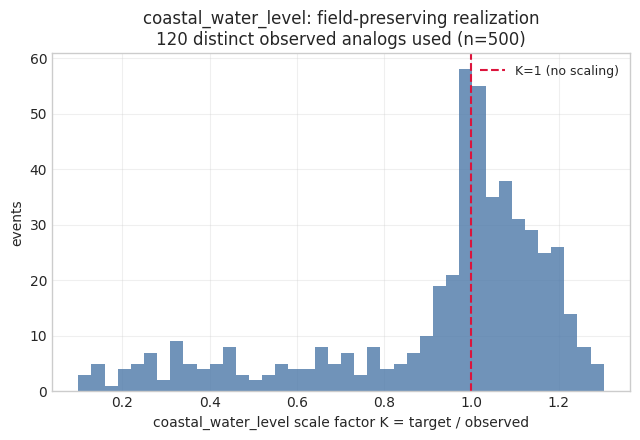

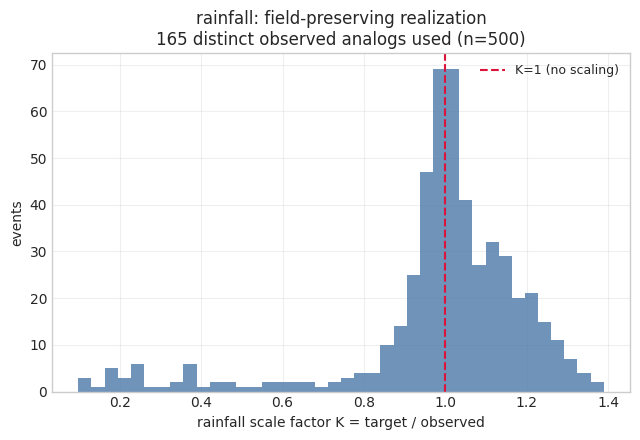

In [23]:
# field-preserving member libraries and joint synthetic design catalog.
display(pd.Series({
    "copula_engine": "pyvinecopulib",
    "candidate_pool_count": dependence_policy["pool_size"],
    "target_event_count": resilience_stress_training["target_event_count"],
    "benchmark_return_periods": resilience_stress_training["benchmark_return_period_years"],
    "severity_band_fractions": resilience_stress_training["severity_band_fractions"],
    "storm_type_populations_enabled": dependence_policy["storm_stratification"]["enabled"],
    "compound_pairing_strategy": resilience_stress_training["compound_pairing"]["strategy"],
}, name="copula_sampling_parameters"))

joint_member_libraries = build_member_libraries(config, location_root=location_root)
joint_result = build_joint_catalog(
    config,
    {"location_root": location_root, "location_name": location_name, "scenario": {"name": "base"}},
    paired_observations=joint_paired,
    member_libraries=joint_member_libraries,
)
joint_catalog = joint_result.catalog
historical_tail_catalog = build_tail(
    joint_paired,
    joint_result.model,
    config,
    {"location_root": location_root, "location_name": location_name, "scenario": {"name": "base"}},
    member_libraries=joint_member_libraries,
)
historical_tail_catalog_path = paths["catalog_root"] / "historical_tail_catalog.csv"
historical_tail_catalog_path.parent.mkdir(parents=True, exist_ok=True)
historical_tail_catalog.to_csv(historical_tail_catalog_path, index=False)
joint_catalog_for_scenarios = pd.concat([joint_catalog, historical_tail_catalog], ignore_index=True, sort=False)
joint_catalog_for_scenarios = attach_antecedent_soil_moisture(
    joint_catalog_for_scenarios, soil_moisture_members, config=config
)

print(
    f"realized base rate {joint_paired.attrs['base_event_rate_per_year']:.2f}/yr "
    f"(threshold calibrated to {joint_paired.attrs['target_rate_per_year']:.0f}/yr over "
    f"{joint_paired.attrs['record_years']:.0f} yr)"
)
display(joint_result.population_report)
display(joint_result.budget_report)

P.plot_storm_type_cooccurrence(joint_paired, joint_driver_vector[0], joint_driver_vector[1]);
P.plot_population_copula_fits(joint_result.model, joint_paired);
P.plot_combined_and_isolines(
    joint_result.model,
    return_periods=benchmark_return_periods,
    catalog=joint_catalog,
);
for _driver in joint_driver_vector:
    P.plot_scaling(joint_catalog, _driver);

display(pd.Series({
    "paired_observation_rows": len(joint_paired),
    "copula_joint_catalog_rows": len(joint_catalog),
    "historical_tail_rows": len(historical_tail_catalog),
    "scenario_handoff_rows": len(joint_catalog_for_scenarios),
    "driver_vector": ", ".join(joint_driver_vector),
    "storm_type_populations": ", ".join(
        f"{row.storm_type}:{int(row.n_events)}" for row in joint_result.population_report.itertuples()
    ),
    "mixture_total_rate_per_year": round(joint_result.model.total_rate, 2),
    "forcing_pairing_policy": joint_catalog["forcing_pairing_policy"].iloc[0],
    "stress_budget_met": bool(
        joint_result.budget_report.loc[joint_result.budget_report["stress_budget_count"] > 0, "meets_budget"].all()
    ),
    "historical_tail_csv": str(historical_tail_catalog_path),
}, name="copula_joint_summary"))


# Persist the per-storm-type copula fit report so the sparse-population (e.g. TC) fit-quality
# caveat is auditable for peer review, not display-only.
storm_type_population_report_path = paths["catalog_root"] / "storm_type_population_report.csv"
joint_result.population_report.to_csv(storm_type_population_report_path, index=False)
display(pd.Series({"storm_type_population_report_csv": str(storm_type_population_report_path)}, name="copula_fit_provenance"))

## Annualization rate for downstream FIAT risk.

In [24]:
# Expected Annual Damage needs the copula mixture occurrence rate: annual_rate_i = total_rate_per_year * probability_weight_i
catalog_risk_metadata = {
    "total_rate_per_year": float(joint_result.model.total_rate),
    "base_event_rate_per_year": float(
        joint_paired.attrs.get("base_event_rate_per_year", dependence_policy.get("event_rate_per_year"))
    ),
    "record_years": float(joint_paired.attrs.get("record_years")),
    "weight_basis": (
        "probability_weight sums to 1 over synthetic events; "
        "annual_rate = total_rate_per_year * probability_weight"
    ),
    "severity_band_fractions": config["resilience_stress_training"]["severity_band_fractions"],
    "event_origins_excluded_from_ead": ["historical_tail"],
    "driver_vector": joint_driver_vector,
}
catalog_risk_metadata_path = paths["catalog_root"] / "catalog_risk_metadata.json"
catalog_risk_metadata_path.write_text(json.dumps(catalog_risk_metadata, indent=2), encoding="utf-8")
display(pd.Series(catalog_risk_metadata, name="catalog_risk_metadata"))

total_rate_per_year                                                         8.927979
base_event_rate_per_year                                                    8.927979
record_years                                                               43.906913
weight_basis                       probability_weight sums to 1 over synthetic ev...
severity_band_fractions            {'mild': 0.05, 'common': 0.2, 'significant': 0...
event_origins_excluded_from_ead                                    [historical_tail]
driver_vector                                        [coastal_water_level, rainfall]
Name: catalog_risk_metadata, dtype: object

## Stage 4 — Copula-joint design catalog and resilience stress/training set

The fitted joint catalog is audited with combined-driver isolines, driver scaling plots, and return-period benchmark coverage. The selected 500-row design/stress set remains intentionally enriched across severity bands for SFINCS/DNMG scenario coverage.

- Unweighted event count shows the run budget allocation.
- `probability_weight` shows the fitted probability mass each enriched row represents.
- Benchmark plots verify coverage near 10, 50, 100, and 500 year driver return periods.

### 4.1 Selected Design Catalog Severity Ranges

mild/common/significant/rare/extreme labels

In [25]:
# severity-band ranges for selected coastal design catalog.
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["and_joint_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "and_joint_return_period_range", "annual_chance_range"]])

,severity_band,and_joint_return_period_range,annual_chance_range
0,mild,0 to <2 yr,> 50%
1,common,2 to <10 yr,> 10% to <= 50%
2,significant,10 to <50 yr,> 2% to <= 10%
3,rare,50 to <100 yr,> 1% to <= 2%
4,extreme,100 to <500 yr,> 0.2% to <= 1%
5,beyond_design,>= 500 yr,<= 0.2%


### 4.2 Resilience Stress/Training Set Coverage

The coastal joint catalog is generated as a 500-event band-stratified importance sample from the fitted candidate pool. This block writes the operational resilience stress/training set and keeps the compact severity-band and benchmark-coverage checks without repeating the budget/probability-mass figure.

stress_training_rows                                                     500
sampling_scheme                                   band_stratified_importance
mild_rows                                                                 25
mild_fraction                                                           0.05
probability_weight_sum                                                   1.0
stress_training_csv        /home/grahamhults/projects/Flood-RM/locations/...
compound_pairing_policy            operationally_severe_plausible_dependence
Name: resilience_stress_training, dtype: object

,event_id,sample_rp_years,severity_band,sampling_weight,probability_weight,benchmark_return_period_years,selection_reason,compound_pairing_role,scenario_timing_edge_case,rainfall_metric_mm
499,design_0467,475.08,extreme,0.028,0.000056,500,nearest_0p2pct_annual_chance_event_driver;tail...,historical_coastal_rainfall_pair,historical-compound-pair,297.733933
349,design_0303,99.44,rare,0.040,0.000081,100,nearest_1pct_annual_chance_event_driver;tail_o...,wet_soil_high_rainfall,wet-soil-high-rain,297.733933
224,design_0200,49.99,significant,0.286,0.000574,50,nearest_2pct_annual_chance_event_driver;tail_o...,high_rainfall_cooccurrence,high-rainfall-cooccurrence-observed-lag,240.052682
125,design_0205,10.01,significant,0.286,0.000574,10,nearest_10pct_annual_chance_event_driver;tail_...,rainfall_before_coastal,rainfall-before-coastal,240.052682
498,design_0381,475.08,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,198.904467
497,design_0400,463.88,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,157.230359
496,design_0473,459.97,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,60.034822
495,design_0490,427.58,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,216.241968
494,design_0493,418.48,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,192.155360
493,design_0417,390.25,extreme,0.028,0.000056,NaN,tail_or_benchmark_event_driver,historical_coastal_rainfall_pair,historical-compound-pair,163.275002


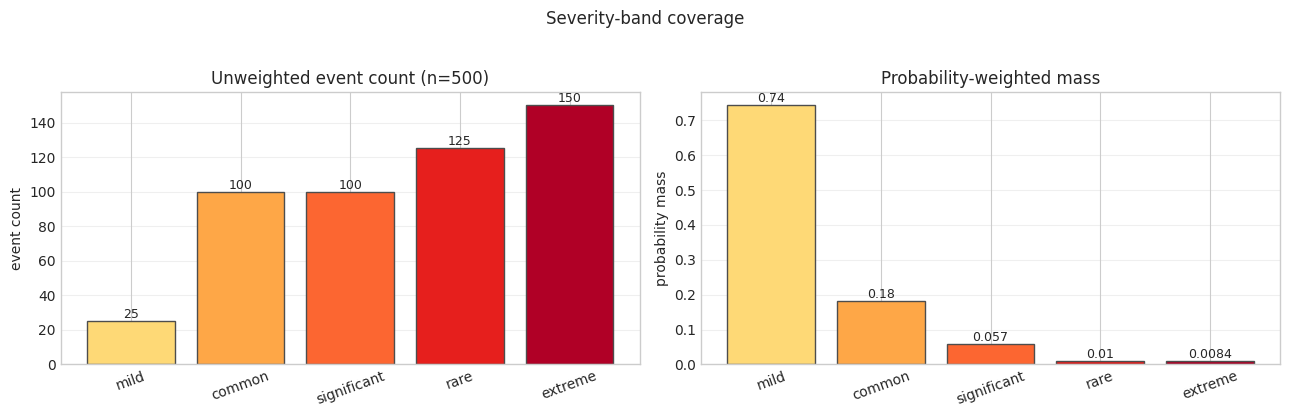

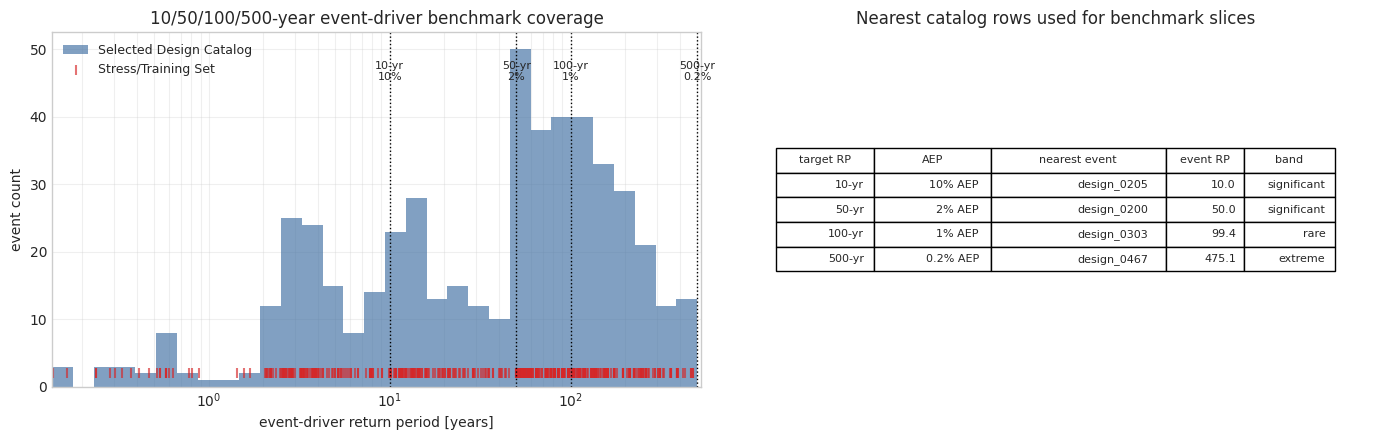

In [26]:
# high-fidelity simulation budget coverage by severity.
benchmark_return_periods = config["resilience_stress_training"]["benchmark_return_period_years"]
# Sample compound lags from the observed co-occurrence pool (peak RF relative to peak NTR) so
# realistic co-occurrence events reflect observed timing instead of coincident peaks
# (Maduwantha et al. 2026, Fig 2p / Sec 4.3.4).
_cooc = joint_paired.dropna(subset=["rainfall_time", "coastal_water_level_time"]).copy()
config["resilience_stress_training"].setdefault("compound_pairing", {})["observed_cooccurrence_lags"] = (
    (pd.to_datetime(_cooc["rainfall_time"]) - pd.to_datetime(_cooc["coastal_water_level_time"])).dt.total_seconds() / 3600.0
).tolist()
stress_training_catalog = select_training(
    joint_catalog,
    rainfall_members=rainfall_members,
    soil_moisture_members=soil_moisture_members,
    config=config,
)
paths["resilience_stress_training_catalog_csv"].parent.mkdir(parents=True, exist_ok=True)
stress_training_catalog.to_csv(paths["resilience_stress_training_catalog_csv"], index=False)

P.plot_severity_bands(stress_training_catalog);
P.plot_return_period_benchmark_coverage(
    joint_catalog,
    stress_catalog=stress_training_catalog,
    benchmarks=benchmark_return_periods,
);

stress_summary = pd.Series({
    "stress_training_rows": len(stress_training_catalog),
    "sampling_scheme": stress_training_catalog.get("sampling_scheme", pd.Series([pd.NA])).dropna().iloc[0]
    if "sampling_scheme" in stress_training_catalog and stress_training_catalog["sampling_scheme"].notna().any() else pd.NA,
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "probability_weight_sum": float(pd.to_numeric(stress_training_catalog["probability_weight"], errors="coerce").sum()),
    "stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
    "compound_pairing_policy": stress_training_catalog.get("compound_pairing_policy", pd.Series([pd.NA])).dropna().iloc[0]
    if "compound_pairing_policy" in stress_training_catalog and stress_training_catalog["compound_pairing_policy"].notna().any() else pd.NA,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.assign(
    has_benchmark=stress_training_catalog["benchmark_return_period_years"].notna(),
    is_mild=stress_training_catalog["severity_band"].eq("mild"),
).sort_values(
    ["has_benchmark", "is_mild", "sample_rp_years"],
    ascending=[False, True, False],
)
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "sampling_weight", "probability_weight",
    "benchmark_return_period_years", "selection_reason",
    "compound_pairing_role", "scenario_timing_edge_case", "rainfall_metric_mm",
]].head(16).round({"sample_rp_years": 2, "sampling_weight": 3, "probability_weight": 8}))


### 4.3 Joint Catalog Row Preview

Every row carries the sampled driver values, observed analog member ids, realization scale factors, probability weight, stress-selection metadata, and infiltration treatment that the downstream SFINCS workflow needs.

In [27]:
# selected catalog columns for reviewer scan.
catalog_preview_columns = [
    "event_id", "event_origin", "catalog_role", "scenario_name", "storm_type", "sample_rp_years", "severity_band", "sampling_region",
    "sampling_weight", "probability_weight", "benchmark_return_period_years", "selection_reason",
    "coastal_water_level", "coastal_water_level_member_id",
    "coastal_water_level_template_member_id", "coastal_water_level_scale_factor",
    "rainfall", "rainfall_member_id", "rainfall_scale_factor",
    "forcing_pairing_policy", "event_drivers", "infiltration_treatment",
]
present_columns = [column for column in catalog_preview_columns if column in joint_catalog_for_scenarios.columns]
display(joint_catalog_for_scenarios[present_columns].head(5))

candidate_pool_count = pd.NA
if "candidate_pool_count" in joint_catalog and joint_catalog["candidate_pool_count"].notna().any():
    candidate_pool_count = int(pd.to_numeric(joint_catalog["candidate_pool_count"], errors="coerce").dropna().iloc[0])

display(pd.Series({
    "forcing_pairing_policy": joint_catalog["forcing_pairing_policy"].iloc[0],
    "synthetic_design_rows": len(joint_catalog),
    "historical_tail_rows": len(historical_tail_catalog),
    "handoff_rows": len(joint_catalog_for_scenarios),
    "candidate_pool_count": candidate_pool_count,
    "origin_counts": ", ".join(f"{k}:{v}" for k, v in joint_catalog_for_scenarios["event_origin"].value_counts().items())
    if "event_origin" in joint_catalog_for_scenarios else pd.NA,
    "stress_training_rows": len(stress_training_catalog),
    "stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
}, name="joint_catalog_handoff"))

# SFINCS scenario builder contract: write the realized coastal hydrographs and forcing metadata.
sfincs_handoff = write_handoff(joint_catalog_for_scenarios, components, config=config, paths=paths)
display(pd.Series({
    "event_catalog_rows": len(sfincs_handoff["catalog"]),
    "audit_passed": sfincs_handoff["audit"]["passed"],
    "event_members_nc": str(paths["event_members_nc"]),
    "event_catalog_csv": str(paths["event_catalog_csv"]),
}, name="sfincs_scenario_handoff"))


,event_id,event_origin,catalog_role,scenario_name,storm_type,sample_rp_years,severity_band,sampling_region,sampling_weight,probability_weight,benchmark_return_period_years,selection_reason,coastal_water_level,coastal_water_level_member_id,coastal_water_level_template_member_id,coastal_water_level_scale_factor,rainfall,rainfall_member_id,rainfall_scale_factor,forcing_pairing_policy,event_drivers,infiltration_treatment
0,design_0017,synthetic_body,design,base,other_non_tropical,0.135918,mild,body,14.815,0.029733,NaN,NaN,0.065258,coastal_water_level_20200427T200000,coastal_water_level_20200427T200000,0.135772,22.947459,rainfall_marshfield_72h_rank0448,0.363993,copula_joint,"coastal_water_level, rainfall",none
1,design_0005,synthetic_body,design,base,nor_easter,0.137691,mild,body,14.815,0.029733,NaN,NaN,0.122684,coastal_water_level_19870131T170000,coastal_water_level_19870131T170000,0.278033,13.296409,rainfall_marshfield_72h_rank0475,0.217087,copula_joint,"coastal_water_level, rainfall",none
2,design_0011,synthetic_body,design,base,nor_easter,0.163914,mild,body,14.815,0.029733,NaN,NaN,0.184687,coastal_water_level_19870131T170000,coastal_water_level_19870131T170000,0.418550,14.545460,rainfall_marshfield_72h_rank0492,0.240805,copula_joint,"coastal_water_level, rainfall",none
3,design_0014,synthetic_body,design,base,nor_easter,0.237923,mild,body,14.815,0.029733,NaN,NaN,0.222638,coastal_water_level_19870131T170000,coastal_water_level_19870131T170000,0.504555,39.128566,rainfall_marshfield_72h_rank0495,0.651765,copula_joint,"coastal_water_level, rainfall",none
4,design_0021,synthetic_body,design,base,other_non_tropical,0.238538,mild,body,14.815,0.029733,NaN,NaN,0.256676,coastal_water_level_20111208T080000,coastal_water_level_20111208T080000,0.581318,31.356249,rainfall_marshfield_72h_rank0435,0.488850,copula_joint,"coastal_water_level, rainfall",none


forcing_pairing_policy                                         copula_joint
synthetic_design_rows                                                   500
historical_tail_rows                                                     10
handoff_rows                                                            510
candidate_pool_count                                                 100000
origin_counts             synthetic_tail:375, synthetic_body:125, histor...
stress_training_rows                                                    500
stress_training_csv       /home/grahamhults/projects/Flood-RM/locations/...
Name: joint_catalog_handoff, dtype: object

event_catalog_rows                                                  510
audit_passed                                                       True
event_members_nc      /home/grahamhults/projects/Flood-RM/locations/...
event_catalog_csv     /home/grahamhults/projects/Flood-RM/locations/...
Name: sfincs_scenario_handoff, dtype: object

## Stage 5 — Hand off to SFINCS (tide-preserving NTR realization + SLR)

The coastal SFINCS water-level boundary is built from the selected catalog. Each event names an observed surge (NTR) analog and a scale factor `K`.

- Only the NTR/surge component is scaled.
- Astronomical tide and mean sea level are added back unscaled, preserving tide-surge phasing.
- SLR scenarios apply a rigid mean-sea-level offset after the event realization.

,slr_offset_m
scenario_name,
base,0.0
noaa_int_2050,0.3
noaa_int_2100,1.1


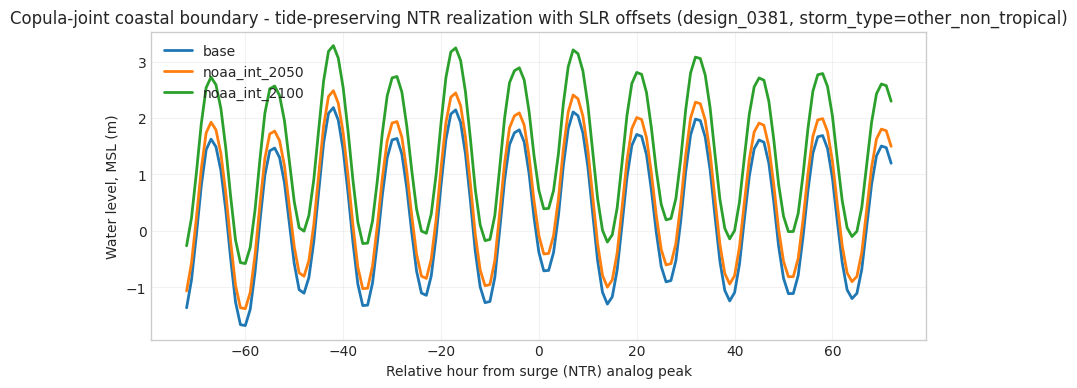

,event_id,sample_rp_years,severity_band,storm_type,ntr_analog_peak_time,ntr_scale_factor,msl_offset_m,peak_water_level_msl
scenario_name,,,,,,,,
base,design_0381,475.08466,extreme,other_non_tropical,2018-11-27T11:00:00,0.971,0.0,2.186
noaa_int_2050,design_0381,475.08466,extreme,other_non_tropical,2018-11-27T11:00:00,0.971,0.3,2.486
noaa_int_2100,design_0381,475.08466,extreme,other_non_tropical,2018-11-27T11:00:00,0.971,1.1,3.286


,base,noaa_int_2050,noaa_int_2100
relative_hour,,,
-72,-1.364747,-1.064747,-0.264747
-71,-0.869399,-0.569399,0.230601
-70,-0.071344,0.228656,1.028656
-69,0.798930,1.098930,1.898930
-68,1.439824,1.739824,2.539824
-67,1.627049,1.927049,2.727049
-66,1.491134,1.791134,2.591134
-65,1.075015,1.375015,2.175015
-64,0.375982,0.675982,1.475982


In [28]:
# SFINCS boundary forcing and sea-level-rise offsets.
sea_level_rise_scenarios = config["scenarios"]

scenario_table = pd.DataFrame.from_dict(sea_level_rise_scenarios, orient="index")
scenario_table.index.name = "scenario_name"
scenario_table["slr_offset_m"] = pd.to_numeric(scenario_table["slr_offset_m"], errors="coerce").fillna(0.0)
display(scenario_table[["slr_offset_m"]])

example_row = joint_catalog.sort_values("sample_rp_years", ascending=False).iloc[0]
scenario_forcings = {
    name: build_timeseries(example_row, components, msl_offset_m=float(row["slr_offset_m"]))
    for name, row in scenario_table.iterrows()
}
slr_forcing_frame = pd.concat(
    {name: forcing["h"].rename(name) for name, forcing in scenario_forcings.items()},
    axis=1,
)

ax = slr_forcing_frame.plot(figsize=(10, 4), linewidth=2)
ax.set_title(
    f"Copula-joint coastal boundary - tide-preserving NTR realization with SLR offsets "
    f"({example_row['event_id']}, storm_type={example_row.get('storm_type', 'n/a')})"
)
ax.set_xlabel("Relative hour from surge (NTR) analog peak")
ax.set_ylabel("Water level, MSL (m)")
ax.grid(True, alpha=0.25)
plt.show()

display(pd.DataFrame({
    "event_id": str(example_row["event_id"]),
    "sample_rp_years": float(example_row["sample_rp_years"]),
    "severity_band": str(example_row["severity_band"]),
    "storm_type": str(example_row.get("storm_type", "n/a")),
    "ntr_analog_peak_time": {name: forcing["analog_peak_time"] for name, forcing in scenario_forcings.items()},
    "ntr_scale_factor": {name: round(forcing["scale_factor"], 3) for name, forcing in scenario_forcings.items()},
    "msl_offset_m": {name: forcing["msl_offset_m"] for name, forcing in scenario_forcings.items()},
    "peak_water_level_msl": slr_forcing_frame.max().round(3),
}).rename_axis("scenario_name"))
slr_forcing_frame.head(12)